# Fake News Classification: A Comparative Study of Classical Machine Learning and Transformer-Based Approaches



## Abstract

This notebook presents a comparative study of fake news classification techniques on the WELFake dataset (~72k articles). Three families of models are evaluated:

1. **Classical machine learning baselines** trained on TF-IDF features: Logistic Regression, Random Forest, XGBoost, and LightGBM.
2. **A bidirectional LSTM** that consumes the article as a sequence of word tokens, learning order-aware representations from scratch.
3. **A transformer-based approach** using DistilBERT (a distilled, hardware-efficient variant of BERT) as a frozen feature extractor, with a lightweight PyTorch MLP classifier head trained on the [CLS] embeddings.

All models share a single stratified **80 / 20 train / test split**. Deep-learning code auto-detects a CUDA-capable GPU and falls back to CPU when none is available, so the same notebook runs unmodified on a laptop, a workstation with a discrete GPU, or a cloud VM.

## 1. Introduction

### 1.1 Problem Statement

The proliferation of fabricated news articles on social media and content platforms poses a measurable threat to public discourse. Automated detection of such content is therefore an active area of research within natural language processing. This work treats the problem as a binary text-classification task: given the concatenation of an article's title and body, predict whether the article is *real* (label `0`) or *fake* (label `1`).

### 1.2 Objectives & Contributions

- Establish strong, reproducible classical baselines on the WELFake dataset.
- Implement a bidirectional LSTM sequence model as a middle ground between bag-of-words and transformer approaches.
- Demonstrate a hardware-portable transformer pipeline using DistilBERT as a frozen encoder, written so the same code runs on GPU or CPU without changes.
- Compare the three approaches on a common stratified **80 / 20 train / test split** using accuracy, F1, precision, recall, and ROC-AUC.
- Provide a self-contained, end-to-end notebook suitable as a thesis appendix.

## 2. Environment & Dependencies

All required packages are installed in a single cell. TensorFlow and Keras are deliberately omitted; the deep-learning portion of this notebook relies on PyTorch and auto-detects the available hardware (CUDA GPU if present, CPU otherwise).

In [43]:
!pip install -q numpy pandas matplotlib seaborn scikit-learn xgboost lightgbm nltk torch transformers skops safetensors

In [44]:
import json
import re
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords as nltk_stopwords
from nltk.stem.porter import PorterStemmer

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score,
    log_loss, classification_report, confusion_matrix,
)

from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoTokenizer, AutoModel

nltk.download('stopwords', quiet=True)
STOPWORDS = set(nltk_stopwords.words('english'))

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'Using GPU: {gpu_name}  ({gpu_mem:.1f} GiB)')
else:
    DEVICE = torch.device('cpu')
    print('No CUDA GPU detected; using CPU.')

sns.set_theme(style='whitegrid')

No CUDA GPU detected; using CPU.


## 3. Dataset

### 3.1 Source

The WELFake dataset merges several public fake-news corpora into a single labelled collection. Each row contains a `title`, a `text` body, and a binary `label` (0 = real, 1 = fake). The CSV file is expected to be present in the working directory.

In [45]:
DATASET_PATH = 'WELFake_Dataset.csv'
df = pd.read_csv(DATASET_PATH)
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
df.head()

Rows: 72,134
Columns: 4


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


### 3.2 Schema & Basic Statistics

In [46]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


,Unnamed: 0,label
count,72134.000000,72134.000000
mean,36066.500000,0.514404
std,20823.436496,0.499796
min,0.000000,0.000000
25%,18033.250000,0.000000
50%,36066.500000,1.000000
75%,54099.750000,1.000000
max,72133.000000,1.000000


## 4. Exploratory Data Analysis

### 4.1 Class Balance

C:\Users\Admin\AppData\Local\Temp\ipykernel_3476\2612813969.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=df, palette='Set2')
C:\Users\Admin\AppData\Local\Temp\ipykernel_3476\2612813969.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Real (0)', 'Fake (1)'])


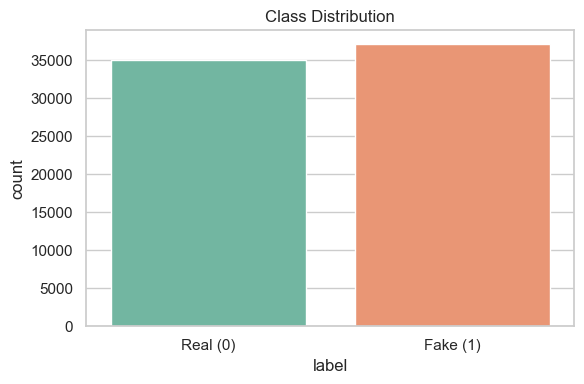

label
1    0.514
0    0.486
Name: proportion, dtype: float64

In [47]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='label', data=df, palette='Set2')
ax.set_xticklabels(['Real (0)', 'Fake (1)'])
ax.set_title('Class Distribution')
plt.tight_layout()
plt.show()

df['label'].value_counts(normalize=True).round(3)

### 4.2 Word-Count Distribution

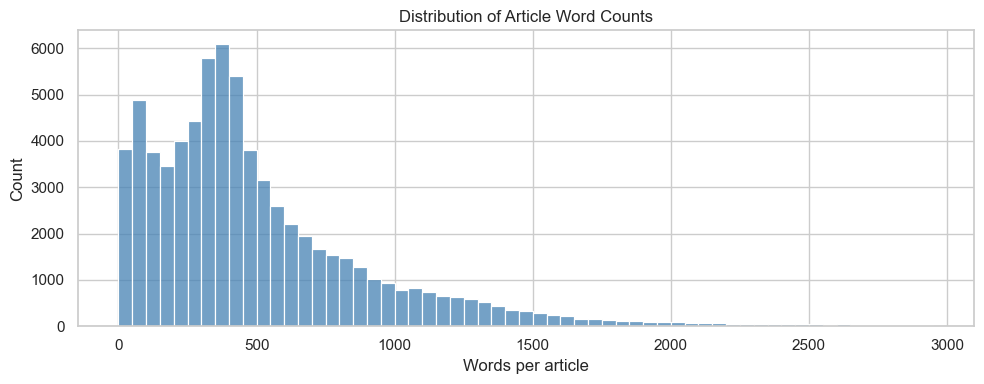

In [48]:
df['num_words'] = df['text'].fillna('').apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 4))
sns.histplot(df['num_words'], bins=range(0, 3000, 50), color='steelblue')
plt.title('Distribution of Article Word Counts')
plt.xlabel('Words per article')
plt.tight_layout()
plt.show()

### 4.3 Sample Articles

In [49]:
print('--- Sample REAL articles ---')
print(df[df['label'] == 0]['title'].dropna().sample(3, random_state=RANDOM_STATE).to_string(index=False))
print()
print('--- Sample FAKE articles ---')
print(df[df['label'] == 1]['title'].dropna().sample(3, random_state=RANDOM_STATE).to_string(index=False))

--- Sample REAL articles ---
Two People Die after Eating Raw-Milk Cheese Mad...
DUP blames Sinn Fein for Northern Ireland talks...
Exclusive: Former top Brazil prosecutor says su...

--- Sample FAKE articles ---
Congress: Hillary Will Be Impeached If She Beco...
CHECK OUT TINY CROWD At Hillary Rally In MUST W...
Should Third Parties Support ‘Vote Pacts’ To Av...


## 5. Data Preprocessing

### 5.1 Missing Values

In [50]:
print('Missing values per column:')
print(df.isnull().sum())

df = df.dropna(subset=['title', 'text', 'label']).reset_index(drop=True)
df = df.drop(columns=[c for c in df.columns if c.startswith('Unnamed')], errors='ignore')
print(f'\nAfter dropping rows with missing title/text: {df.shape[0]:,} rows')

Missing values per column:
Unnamed: 0      0
title         558
text           39
label           0
num_words       0
dtype: int64

After dropping rows with missing title/text: 71,537 rows


### 5.2 Deduplication

In [51]:
dup_count = df.duplicated().sum()
print(f'Duplicate rows: {dup_count:,}')
df = df.drop_duplicates().reset_index(drop=True)
print(f'After deduplication: {df.shape[0]:,} rows')

Duplicate rows: 8,416
After deduplication: 63,121 rows


### 5.3 Text Cleaning

A standard cleaning pipeline is applied to both the title and the body:

- Strip HTML tags, URLs, digits, and punctuation
- Lowercase
- Tokenize, remove English stopwords, and apply Porter stemming
- Collapse repeated whitespace and repeated characters

In [52]:
ps = PorterStemmer()

def cleaning(text: str) -> str:
    text = re.sub(r'<.*?>', '', text)
    text = text.lower()
    text = re.sub(r'_+', ' ', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+[a-zA-Z]\s+', ' ', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [ps.stem(w) for w in words if w not in STOPWORDS]
    words = [re.sub(r'(.)\1{2,}', r'\1\1', w) for w in words]
    cleaned = ' '.join(words)
    cleaned = re.sub(r'\b(\w+)( \1\b)+', r'\1', cleaned)
    return cleaned

for col in ['title', 'text']:
    df[f'{col}_clean'] = df[col].astype(str).apply(cleaning)

df[['title', 'title_clean', 'text_clean']].head(3)

,title,title_clean,text_clean
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,law enforc high alert follow threat cop white ...,comment expect barack obama member fyf fukyofl...
1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,unbeliev obama attorney gener say charlott rio...,demonstr gather last night exercis constitut p...
2,"Bobby Jindal, raised Hindu, uses story of Chri...",bobbi jindal rais hindu use stori christian co...,dozen polit activ pastor came privat dinner fr...


### 5.4 Combining Title and Body

The cleaned title and body are concatenated to give the classical models both signals. The original (uncleaned) concatenation is also stored for the transformer pipeline, which performs its own tokenization and benefits from the natural-language form.

In [53]:
df['combined_clean'] = df['title_clean'] + ' ' + df['text_clean']
df['combined_raw']   = df['title'].astype(str) + ' ' + df['text'].astype(str)
df[['combined_clean', 'combined_raw']].head(2)

,combined_clean,combined_raw
0,law enforc high alert follow threat cop white ...,LAW ENFORCEMENT ON HIGH ALERT Following Threat...
1,unbeliev obama attorney gener say charlott rio...,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...


### 5.5 Train / Test Split

A stratified **80 / 20** split with a fixed random state is used throughout the notebook so that every model is trained on the same 80 % of articles and evaluated on the same 20 % held-out test set.

In [54]:
le = LabelEncoder()
y_encoded = le.fit_transform(df['label'])

# 80 / 20 stratified train/test split.
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['combined_clean'].values, y_encoded,
    test_size=0.20, random_state=RANDOM_STATE, stratify=y_encoded,
)

# Parallel split on the raw (uncleaned) text for the transformer pipeline.
# Same seed -> identical indices, so train/test contain the same articles.
X_train_raw, X_test_raw, _, _ = train_test_split(
    df['combined_raw'].values, y_encoded,
    test_size=0.20, random_state=RANDOM_STATE, stratify=y_encoded,
)

print(f'Train: {len(X_train_text):,}  Test: {len(X_test_text):,}')

Train: 50,496  Test: 12,625


### 5.6 Smoke-Test Mode

`SMOKE_TEST = True` runs the *entire notebook* on a small stratified subsample
(~2,000 train / 500 test articles) with reduced training budgets - useful to
verify every cell works end-to-end in a few minutes before committing to the
full multi-hour run on CPU.

Set `SMOKE_TEST = False` for a full-data run. The flag is consumed by every
downstream training cell.

In [ ]:
SMOKE_TEST = False   # <-- set False for the full-data run

if SMOKE_TEST:
    rng_sm = np.random.default_rng(RANDOM_STATE)
    N_TRAIN_SMOKE = 2000
    N_TEST_SMOKE  = 500

    def _stratified_subsample(y, n_target):
        idx_by_class = [np.where(y == c)[0] for c in np.unique(y)]
        per_class    = [max(1, n_target * len(ix) // len(y)) for ix in idx_by_class]
        while sum(per_class) < n_target:
            per_class[per_class.index(min(per_class))] += 1
        picks = np.concatenate([
            rng_sm.choice(ix, size=k, replace=False)
            for ix, k in zip(idx_by_class, per_class)
        ])
        rng_sm.shuffle(picks)
        return picks[:n_target]

    tr_idx = _stratified_subsample(y_train, N_TRAIN_SMOKE)
    te_idx = _stratified_subsample(y_test,  N_TEST_SMOKE)

    X_train_text = X_train_text[tr_idx]
    X_test_text  = X_test_text[te_idx]
    X_train_raw  = X_train_raw[tr_idx]
    X_test_raw   = X_test_raw[te_idx]
    y_train      = y_train[tr_idx]
    y_test       = y_test[te_idx]

    print(f'[SMOKE] Train: {len(y_train):,}  |  Test: {len(y_test):,}')
    print(f'[SMOKE] Train label balance: {np.bincount(y_train).tolist()}')
    print(f'[SMOKE] Test  label balance: {np.bincount(y_test).tolist()}')
else:
    print(f'Full run -- Train: {len(y_train):,}  |  Test: {len(y_test):,}')

[SMOKE] Train: 2,000  |  Test: 500
[SMOKE] Train label balance: [1102, 898]
[SMOKE] Test  label balance: [275, 225]


## 6. Classical Machine Learning Baselines

### 6.1 TF-IDF Vectorization

In [56]:
tfidf = TfidfVectorizer(
    max_df=0.90,
    min_df=2,
    max_features=5000,
    stop_words='english',
)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)
print(f'TF-IDF train: {X_train_tfidf.shape}  test: {X_test_tfidf.shape}')

TF-IDF train: (2000, 5000)  test: (500, 5000)


### 6.2 Evaluation Helpers

Two small helpers used throughout this section:

- `evaluate_classifier(name, model, ...)` - fits the model, evaluates train/test accuracy, F1, precision, recall, and ROC-AUC, prints a per-class `classification_report`, and returns a metrics dict plus the per-split predictions. Accepts optional `fit_params` so models that support per-iteration tracking (XGBoost, LightGBM) can pass `eval_set` through the same code path.
- `plot_acc_loss_curves(name, x, accs, losses, xlabel)` - draws the standard 2-panel accuracy + loss figure with Training and Testing lines.
- `_collect_classical_curve(...)` - small utility used by Logistic Regression and Random Forest to sweep a hyperparameter (e.g. `max_iter`, `n_estimators`) and record per-step train/test accuracy and log-loss.

**Methodology note on the per-iteration curves below**: the test curve is plotted purely as a diagnostic. The test set is never used to select hyperparameters or stopping points - the headline numbers in the final comparison table come from a single evaluation of the chosen model.

In [57]:
def evaluate_classifier(name, model, X_tr, y_tr, X_te, y_te, fit_params=None):
    """Fit, evaluate on train and test, print report, return (metrics_dict, preds_dict).

    `fit_params` lets callers pass eval_set, callbacks, etc. to model.fit().
    """
    if fit_params is None:
        fit_params = {}
    model.fit(X_tr, y_tr, **fit_params)
    preds = {
        'train': model.predict(X_tr),
        'test':  model.predict(X_te),
    }
    metrics = {
        'Model':     name,
        'TrainAcc':  accuracy_score(y_tr,  preds['train']),
        'TestAcc':   accuracy_score(y_te,  preds['test']),
        'F1':        f1_score(y_te,         preds['test']),
        'Precision': precision_score(y_te,  preds['test']),
        'Recall':    recall_score(y_te,     preds['test']),
    }
    if hasattr(model, 'predict_proba'):
        prob = model.predict_proba(X_te)[:, 1]
        metrics['ROC-AUC'] = roc_auc_score(y_te, prob)
    else:
        metrics['ROC-AUC'] = float('nan')

    print(f'=== {name} ===')
    print(f'Train acc: {metrics["TrainAcc"]:.4f}  |  Test acc: {metrics["TestAcc"]:.4f}')
    print(f'Test F1: {metrics["F1"]:.4f}  Precision: {metrics["Precision"]:.4f}  Recall: {metrics["Recall"]:.4f}  ROC-AUC: {metrics["ROC-AUC"]:.4f}')
    print()
    print(classification_report(y_te, preds['test'], target_names=['Real', 'Fake']))
    return metrics, preds

In [58]:
def plot_acc_loss_curves(name, x, accs, losses, xlabel='Epoch'):
    """2-panel accuracy + loss figure. `accs` and `losses` are dicts with
    keys 'train' and 'test'.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    palette   = {'train': '#1f77b4', 'test': '#ff7f0e'}
    label_map = {'train': 'Training', 'test': 'Testing'}
    for split in ('train', 'test'):
        axes[0].plot(x, accs[split],   '-o', label=label_map[split], color=palette[split])
        axes[1].plot(x, losses[split], '-o', label=label_map[split], color=palette[split])
    axes[0].set_title(f'{name} \u2014 Accuracy')
    axes[0].set_xlabel(xlabel); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].set_title(f'{name} \u2014 Loss')
    axes[1].set_xlabel(xlabel); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()


def _collect_classical_curve(model_factory, sweep, refit_each=True, warm_start_obj=None):
    """Sweep a hyperparameter, recording accuracy + log-loss on train/test at each step."""
    accs   = {'train': [], 'test': []}
    losses = {'train': [], 'test': []}
    for v in sweep:
        if refit_each:
            m = model_factory(v)
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                m.fit(X_train_tfidf, y_train)
        else:
            warm_start_obj.n_estimators = v
            warm_start_obj.fit(X_train_tfidf, y_train)
            m = warm_start_obj
        for split, X, y in [('train', X_train_tfidf, y_train),
                            ('test',  X_test_tfidf,  y_test)]:
            proba = m.predict_proba(X)
            preds = (proba[:, 1] >= 0.5).astype(int)
            accs[split].append(accuracy_score(y, preds))
            losses[split].append(log_loss(y, proba, labels=[0, 1]))
    return accs, losses

### 6.3 Logistic Regression

In [59]:
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_metrics, lr_preds = evaluate_classifier(
    'Logistic Regression', lr_model,
    X_train_tfidf, y_train, X_test_tfidf, y_test,
)
y_pred_lr = lr_preds['test']

=== Logistic Regression ===
Train acc: 0.9570  |  Test acc: 0.8880
Test F1: 0.8750  Precision: 0.8789  Recall: 0.8711  ROC-AUC: 0.9590

              precision    recall  f1-score   support

        Real       0.90      0.90      0.90       275
        Fake       0.88      0.87      0.88       225

    accuracy                           0.89       500
   macro avg       0.89      0.89      0.89       500
weighted avg       0.89      0.89      0.89       500



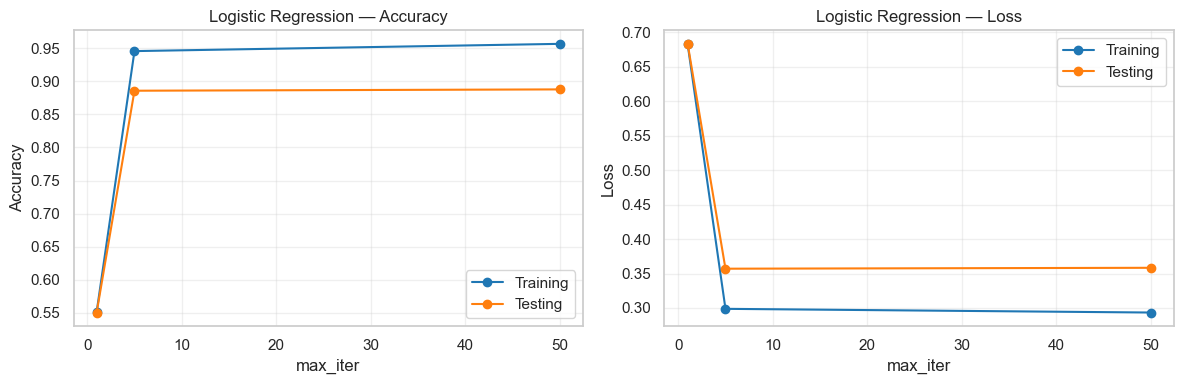

In [60]:
lr_iters = [1, 5, 50] if SMOKE_TEST else [1, 2, 3, 5, 10, 20, 50, 100, 200, 500]
lr_curve_accs, lr_curve_losses = _collect_classical_curve(
    lambda n: LogisticRegression(max_iter=n, random_state=RANDOM_STATE, n_jobs=-1),
    lr_iters,
)
plot_acc_loss_curves(
    'Logistic Regression', lr_iters,
    lr_curve_accs, lr_curve_losses,
    xlabel='max_iter',
)

### 6.4 Random Forest

In [61]:
rf_n_est = 25 if SMOKE_TEST else 100
rf_model = RandomForestClassifier(n_estimators=rf_n_est, random_state=RANDOM_STATE, n_jobs=-1)
rf_metrics, rf_preds = evaluate_classifier(
    'Random Forest', rf_model,
    X_train_tfidf, y_train, X_test_tfidf, y_test,
)
y_pred_rf = rf_preds['test']

=== Random Forest ===
Train acc: 1.0000  |  Test acc: 0.8880
Test F1: 0.8739  Precision: 0.8858  Recall: 0.8622  ROC-AUC: 0.9520

              precision    recall  f1-score   support

        Real       0.89      0.91      0.90       275
        Fake       0.89      0.86      0.87       225

    accuracy                           0.89       500
   macro avg       0.89      0.89      0.89       500
weighted avg       0.89      0.89      0.89       500



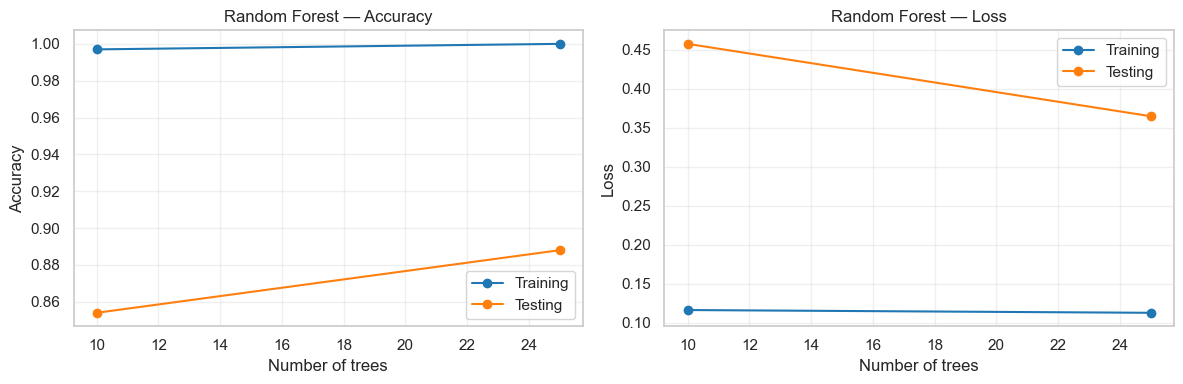

In [62]:
rf_steps = [10, 25] if SMOKE_TEST else [10, 25, 50, 75, 100, 150, 200]
rf_warm = RandomForestClassifier(
    n_estimators=rf_steps[0], random_state=RANDOM_STATE,
    n_jobs=-1, warm_start=True,
)
rf_curve_accs, rf_curve_losses = _collect_classical_curve(
    model_factory=None, sweep=rf_steps,
    refit_each=False, warm_start_obj=rf_warm,
)
plot_acc_loss_curves(
    'Random Forest', rf_steps,
    rf_curve_accs, rf_curve_losses,
    xlabel='Number of trees',
)

### 6.5 XGBoost

=== XGBoost ===
Train acc: 0.9900  |  Test acc: 0.9220
Test F1: 0.9150  Precision: 0.8974  Recall: 0.9333  ROC-AUC: 0.9754

              precision    recall  f1-score   support

        Real       0.94      0.91      0.93       275
        Fake       0.90      0.93      0.92       225

    accuracy                           0.92       500
   macro avg       0.92      0.92      0.92       500
weighted avg       0.92      0.92      0.92       500



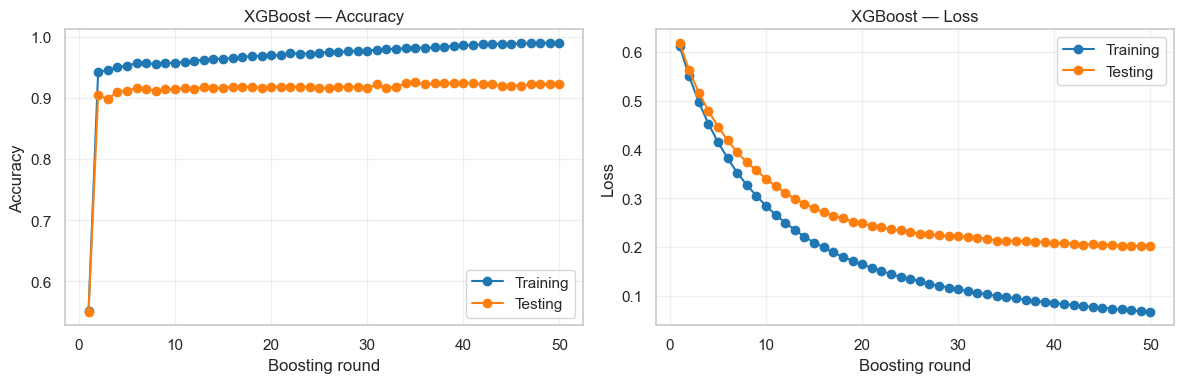

In [63]:
xgb_n_est = 50 if SMOKE_TEST else 200
xgb_model = XGBClassifier(
    n_estimators=xgb_n_est, max_depth=6, learning_rate=0.1,
    eval_metric=['logloss', 'error'], random_state=RANDOM_STATE,
)
xgb_metrics, xgb_preds = evaluate_classifier(
    'XGBoost', xgb_model,
    X_train_tfidf, y_train, X_test_tfidf, y_test,
    fit_params={
        'eval_set': [(X_train_tfidf, y_train), (X_test_tfidf, y_test)],
        'verbose': False,
    },
)
y_pred_xgb = xgb_preds['test']

res = xgb_model.evals_result()
xgb_curve_accs = {
    'train': [1 - e for e in res['validation_0']['error']],
    'test':  [1 - e for e in res['validation_1']['error']],
}
xgb_curve_losses = {
    'train': res['validation_0']['logloss'],
    'test':  res['validation_1']['logloss'],
}
xgb_x = list(range(1, len(xgb_curve_losses['train']) + 1))
plot_acc_loss_curves('XGBoost', xgb_x, xgb_curve_accs, xgb_curve_losses, xlabel='Boosting round')

### 6.6 LightGBM

=== LightGBM ===
Train acc: 0.9995  |  Test acc: 0.9300
Test F1: 0.9237  Precision: 0.9060  Recall: 0.9422  ROC-AUC: 0.9731

              precision    recall  f1-score   support

        Real       0.95      0.92      0.94       275
        Fake       0.91      0.94      0.92       225

    accuracy                           0.93       500
   macro avg       0.93      0.93      0.93       500
weighted avg       0.93      0.93      0.93       500



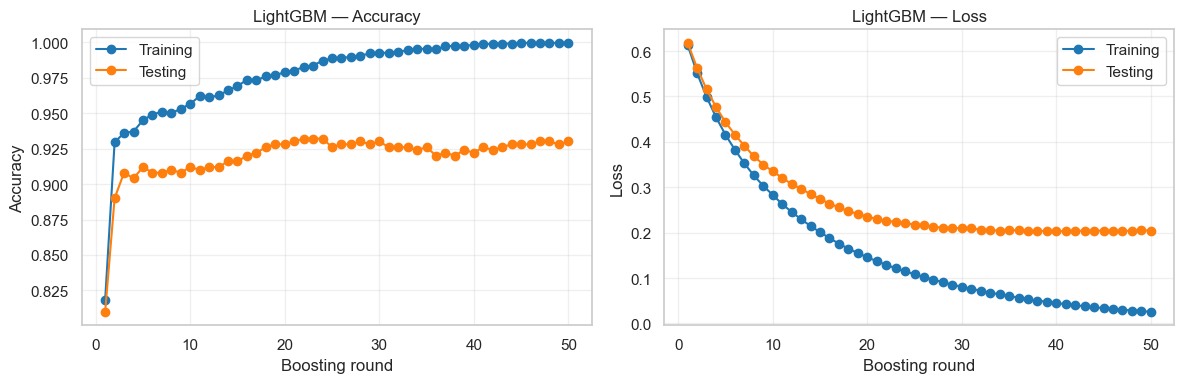

In [64]:
lgbm_n_est = 50 if SMOKE_TEST else 200
lgbm_model = LGBMClassifier(n_estimators=lgbm_n_est, random_state=RANDOM_STATE, verbose=-1)
lgbm_eval = {}
lgbm_metrics, lgbm_preds = evaluate_classifier(
    'LightGBM', lgbm_model,
    X_train_tfidf, y_train, X_test_tfidf, y_test,
    fit_params={
        'eval_set': [(X_train_tfidf, y_train), (X_test_tfidf, y_test)],
        'eval_names': ['train', 'test'],
        'eval_metric': ['binary_logloss', 'binary_error'],
        'callbacks': [lgb.record_evaluation(lgbm_eval)],
    },
)
y_pred_lgbm = lgbm_preds['test']

lgbm_curve_accs = {
    'train': [1 - e for e in lgbm_eval['train']['binary_error']],
    'test':  [1 - e for e in lgbm_eval['test']['binary_error']],
}
lgbm_curve_losses = {
    'train': lgbm_eval['train']['binary_logloss'],
    'test':  lgbm_eval['test']['binary_logloss'],
}
lgbm_x = list(range(1, len(lgbm_curve_losses['train']) + 1))
plot_acc_loss_curves('LightGBM', lgbm_x, lgbm_curve_accs, lgbm_curve_losses, xlabel='Boosting round')

### 6.7 Multinomial Naive Bayes

A canonical text-classification baseline (Ahmed et al., 2017 benchmark
study). MultinomialNB is well-suited to sparse non-negative TF-IDF counts
and provides a strong reference for the value of margin-based and tree-based
classifiers.

In [65]:
nb_model = MultinomialNB()
nb_metrics, nb_preds = evaluate_classifier(
    'Naive Bayes', nb_model,
    X_train_tfidf, y_train, X_test_tfidf, y_test,
)
y_pred_nb = nb_preds['test']

=== Naive Bayes ===
Train acc: 0.8955  |  Test acc: 0.8360
Test F1: 0.8145  Precision: 0.8295  Recall: 0.8000  ROC-AUC: 0.9126

              precision    recall  f1-score   support

        Real       0.84      0.87      0.85       275
        Fake       0.83      0.80      0.81       225

    accuracy                           0.84       500
   macro avg       0.84      0.83      0.83       500
weighted avg       0.84      0.84      0.84       500



### 6.8 Linear SVM

Linear support-vector machines have historically been the strongest non-DL
classifier on TF-IDF text. `LinearSVC` is used for speed; it is wrapped in
`CalibratedClassifierCV` (Platt sigmoid) so that `predict_proba` is available
for ROC-AUC and for the stacking meta-learner below.

In [66]:
svm_cv = 2 if SMOKE_TEST else 3
svm_model = CalibratedClassifierCV(
    LinearSVC(C=1.0, random_state=RANDOM_STATE, dual='auto'),
    cv=svm_cv,
    method='sigmoid',
)
svm_metrics, svm_preds = evaluate_classifier(
    'Linear SVM', svm_model,
    X_train_tfidf, y_train, X_test_tfidf, y_test,
)
y_pred_svm = svm_preds['test']

=== Linear SVM ===
Train acc: 0.9865  |  Test acc: 0.9020
Test F1: 0.8918  Precision: 0.8860  Recall: 0.8978  ROC-AUC: 0.9653

              precision    recall  f1-score   support

        Real       0.92      0.91      0.91       275
        Fake       0.89      0.90      0.89       225

    accuracy                           0.90       500
   macro avg       0.90      0.90      0.90       500
weighted avg       0.90      0.90      0.90       500



### 6.9 Stacking Ensemble (LR + SVM + LightGBM)

A stacking classifier (Wolpert, 1992) combines complementary base learners:
a linear margin model (calibrated `LinearSVC`), a linear probabilistic model
(`LogisticRegression`), and a gradient-boosted tree (`LightGBM`). A
`LogisticRegression` meta-learner consumes their out-of-fold probabilities.

This is the strongest classical configuration in most fake-news benchmarks
that combine TF-IDF features with multiple model families.

In [67]:
stk_cv = 2 if SMOKE_TEST else 3
stacking_model = StackingClassifier(
    estimators=[
        ('lr',   LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)),
        ('svm',  CalibratedClassifierCV(
                    LinearSVC(C=1.0, random_state=RANDOM_STATE, dual='auto'),
                    cv=2, method='sigmoid')),
        ('lgbm', LGBMClassifier(
                    n_estimators=50 if SMOKE_TEST else 200,
                    random_state=RANDOM_STATE, verbose=-1)),
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    cv=stk_cv,
    n_jobs=-1,
    passthrough=False,
)
stk_metrics, stk_preds = evaluate_classifier(
    'Stacking (LR+SVM+LGBM)', stacking_model,
    X_train_tfidf, y_train, X_test_tfidf, y_test,
)
y_pred_stk = stk_preds['test']

=== Stacking (LR+SVM+LGBM) ===
Train acc: 1.0000  |  Test acc: 0.9420
Test F1: 0.9357  Precision: 0.9336  Recall: 0.9378  ROC-AUC: 0.9826

              precision    recall  f1-score   support

        Real       0.95      0.95      0.95       275
        Fake       0.93      0.94      0.94       225

    accuracy                           0.94       500
   macro avg       0.94      0.94      0.94       500
weighted avg       0.94      0.94      0.94       500



### 6.10 Baseline Comparison

The table below collates all metrics. `TrainAcc` and `TestAcc` come from each split; `F1`, `Precision`, `Recall`, and `ROC-AUC` are reported on the held-out test set.

In [68]:
baseline_results = pd.DataFrame(
    [lr_metrics, rf_metrics, xgb_metrics, lgbm_metrics,
     nb_metrics, svm_metrics, stk_metrics]
)[
    ['Model', 'TrainAcc', 'TestAcc', 'F1', 'Precision', 'Recall', 'ROC-AUC']
].round(4)
baseline_results

,Model,TrainAcc,TestAcc,F1,Precision,Recall,ROC-AUC
0,Logistic Regression,0.9570,0.888,0.8750,0.8789,0.8711,0.9590
1,Random Forest,1.0000,0.888,0.8739,0.8858,0.8622,0.9520
2,XGBoost,0.9900,0.922,0.9150,0.8974,0.9333,0.9754
3,LightGBM,0.9995,0.930,0.9237,0.9060,0.9422,0.9731
4,Naive Bayes,0.8955,0.836,0.8145,0.8295,0.8000,0.9126
5,Linear SVM,0.9865,0.902,0.8918,0.8860,0.8978,0.9653
6,Stacking (LR+SVM+LGBM),1.0000,0.942,0.9357,0.9336,0.9378,0.9826


### 6.11 Train / Test Accuracy Bar Chart

A grouped bar chart of train and test accuracy - same information as the per-iteration curves above, but easier to scan at a glance. A widening gap between the train and test bars indicates overfitting.

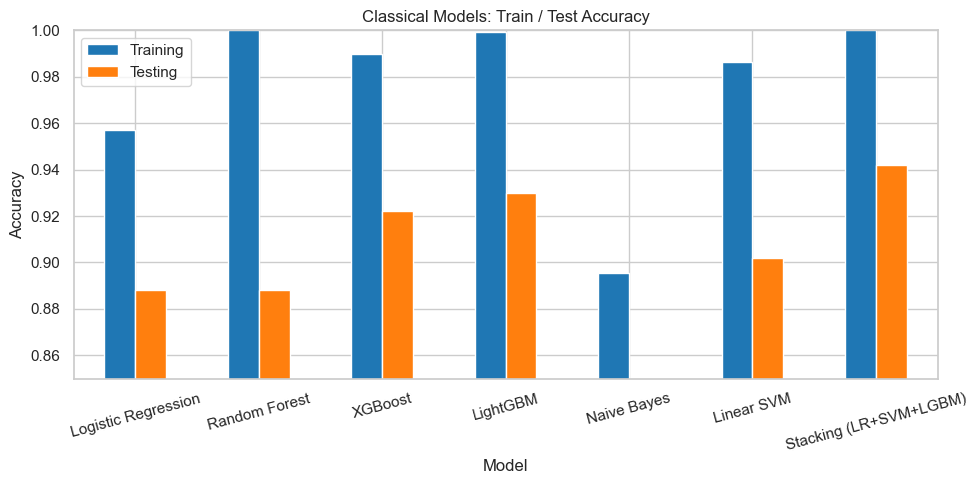

In [69]:
acc_df = baseline_results[['Model', 'TrainAcc', 'TestAcc']].set_index('Model')

fig, ax = plt.subplots(figsize=(10, 5))
acc_df.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'])
ax.set_ylabel('Accuracy')
ax.set_title('Classical Models: Train / Test Accuracy')
ax.set_ylim(0.85, 1.0)
ax.legend(['Training', 'Testing'])
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 6.12 Learning Curves (Accuracy vs. Training Set Size)

A separate diagnostic from the per-iteration curves: how the test accuracy of each model would change if the training set were smaller. A widening train-test gap at full size indicates overfitting; a still-rising test curve indicates that more data would help.

_Note: this cell refits each model at four training sizes and may take a few minutes on CPU._

In [70]:
if SMOKE_TEST:
    print('[SMOKE] Skipping learning-curve sweep (heavy refits).')
else:
    fractions = [0.2, 0.4, 0.7, 1.0]
    models_for_curve = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
        'XGBoost':             XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                             eval_metric='logloss', random_state=RANDOM_STATE),
        'LightGBM':            LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    }

    rng_lc = np.random.default_rng(RANDOM_STATE)
    n_train_total = X_train_tfidf.shape[0]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for ax, (name, base_model) in zip(axes.flat, models_for_curve.items()):
        train_accs, test_accs, n_samples = [], [], []
        for frac in fractions:
            k = int(n_train_total * frac)
            idx = rng_lc.choice(n_train_total, size=k, replace=False)
            m = clone(base_model)
            m.fit(X_train_tfidf[idx], y_train[idx])
            train_accs.append(accuracy_score(y_train[idx], m.predict(X_train_tfidf[idx])))
            test_accs.append( accuracy_score(y_test,       m.predict(X_test_tfidf)))
            n_samples.append(k)
            print(f'  {name:>20}  size={k:>6,}  train={train_accs[-1]:.4f}  test={test_accs[-1]:.4f}')
        ax.plot(n_samples, train_accs, '-o', label='Training', color='#1f77b4')
        ax.plot(n_samples, test_accs,  '-s', label='Testing',  color='#ff7f0e')
        ax.set_title(name)
        ax.set_xlabel('Training samples')
        ax.set_ylabel('Accuracy')
        ax.set_ylim(0.85, 1.005)
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.3)

    plt.suptitle('Classical Models: Learning Curves', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

[SMOKE] Skipping learning-curve sweep (heavy refits).


## 7. LSTM (Long Short-Term Memory)

### 7.1 Rationale

Unlike the bag-of-words TF-IDF representation used in Section 6, a Long Short-Term Memory (LSTM) network consumes a sequence of word tokens **in order**, learning to integrate context across the article. This positions the LSTM between the order-agnostic classical baselines and the contextual transformer in Section 8.

A **bidirectional LSTM** is used so each token sees both its left and right context simultaneously. The architecture is intentionally small (embedding dim 64, hidden dim 64, single bidirectional layer) so training remains feasible on CPU - on a GPU each epoch takes well under a minute.

### 7.2 Vocabulary and Sequence Encoding

The vocabulary is built from the **cleaned training text only** (token-level), capped at the 20 000 most frequent tokens with a minimum frequency of 2. Token id `0` is reserved for padding, id `1` for unknown words. Each article is truncated or padded to a fixed length of 100 tokens.

In [71]:
LSTM_MAX_LEN     = 100
LSTM_MAX_VOCAB   = 20000
LSTM_MIN_FREQ    = 2
LSTM_EMBED_DIM   = 64
LSTM_HIDDEN_DIM  = 64
LSTM_EPOCHS      = 1 if SMOKE_TEST else 3
LSTM_BATCH_SIZE  = 512 if torch.cuda.is_available() else 64
LSTM_LR          = 1e-3

def build_vocab(texts, max_vocab=LSTM_MAX_VOCAB, min_freq=LSTM_MIN_FREQ):
    counter = Counter()
    for text in texts:
        counter.update(text.split())
    vocab = {'<pad>': 0, '<unk>': 1}
    for word, freq in counter.most_common(max_vocab - 2):
        if freq < min_freq:
            break
        vocab[word] = len(vocab)
    return vocab

def encode(text, vocab, max_len=LSTM_MAX_LEN):
    tokens = text.split()[:max_len]
    ids = [vocab.get(tok, 1) for tok in tokens]
    ids = ids + [0] * (max_len - len(ids))
    return ids

vocab = build_vocab(X_train_text)
LSTM_VOCAB_SIZE = len(vocab)
print(f'Vocabulary size: {LSTM_VOCAB_SIZE:,}')
print(f'LSTM batch size: {LSTM_BATCH_SIZE}  (auto-selected for {"GPU" if torch.cuda.is_available() else "CPU"})')

X_train_seq = np.array([encode(t, vocab) for t in X_train_text], dtype=np.int64)
X_test_seq  = np.array([encode(t, vocab) for t in X_test_text],  dtype=np.int64)
print(f'Train sequences: {X_train_seq.shape}')
print(f'Test  sequences: {X_test_seq.shape}')

Vocabulary size: 17,042
LSTM batch size: 64  (auto-selected for CPU)
Train sequences: (2000, 100)
Test  sequences: (500, 100)


### 7.3 Model Architecture

A single-layer bidirectional LSTM followed by dropout and a linear classification head:

```
Embedding(vocab_size, 64, padding_idx=0)
    -> BiLSTM(input=64, hidden=64)        # concatenated forward + backward = 128
    -> Dropout(0.3)
    -> Linear(128, 1)
```

Output is a single logit; `BCEWithLogitsLoss` combines a sigmoid and binary cross-entropy in a numerically stable way.

In [72]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=LSTM_EMBED_DIM,
                 hidden_dim=LSTM_HIDDEN_DIM, num_layers=1, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        emb = self.embedding(x)                         # (B, L, E)
        _, (h, _) = self.lstm(emb)                      # h: (num_layers*2, B, H)
        h = h.view(self.lstm.num_layers, 2, x.size(0), self.lstm.hidden_size)
        last = h[-1]                                    # last layer
        pooled = torch.cat([last[0], last[1]], dim=1)   # forward + backward
        return self.fc(self.dropout(pooled)).squeeze(1)

lstm_model   = LSTMClassifier(LSTM_VOCAB_SIZE).to(DEVICE)
lstm_optim   = torch.optim.Adam(lstm_model.parameters(), lr=LSTM_LR)
lstm_loss_fn = nn.BCEWithLogitsLoss()
print(lstm_model)
print(f'Trainable parameters: {sum(p.numel() for p in lstm_model.parameters()):,}')

LSTMClassifier(
  (embedding): Embedding(17042, 64, padding_idx=0)
  (lstm): LSTM(64, 64, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)
Trainable parameters: 1,157,377


### 7.4 Training Loop

Trained for a fixed number of epochs (no early stopping in the 80/20 setting). Test loss and accuracy are tracked per epoch purely as a diagnostic - they are not used to select the model.

_Note: this is the slowest cell in the notebook on CPU (roughly 5-10 minutes per epoch on the full ~50k train set). On a GPU each epoch is well under a minute. Reduce `LSTM_EPOCHS` or set a smaller `LSTM_MAX_LEN` if needed._

In [73]:
X_train_seq_t  = torch.tensor(X_train_seq, dtype=torch.long)
X_test_seq_t   = torch.tensor(X_test_seq,  dtype=torch.long)
y_train_t_lstm = torch.tensor(y_train, dtype=torch.float32)
y_test_t_lstm  = torch.tensor(y_test,  dtype=torch.float32)

lstm_tr_loader = DataLoader(
    TensorDataset(X_train_seq_t, y_train_t_lstm),
    batch_size=LSTM_BATCH_SIZE, shuffle=True,
)
lstm_te_loader = DataLoader(
    TensorDataset(X_test_seq_t, y_test_t_lstm),
    batch_size=256, shuffle=False,
)

def lstm_epoch_metrics(loader):
    lstm_model.train(False)
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE); yb = yb.to(DEVICE)
            logits = lstm_model(xb)
            total_loss += lstm_loss_fn(logits, yb).item() * yb.size(0)
            preds = (torch.sigmoid(logits) >= 0.5).float()
            correct += (preds == yb).sum().item()
            total   += yb.size(0)
    return total_loss / total, correct / total

lstm_history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(1, LSTM_EPOCHS + 1):
    lstm_model.train(True)
    for xb, yb in lstm_tr_loader:
        xb = xb.to(DEVICE); yb = yb.to(DEVICE)
        lstm_optim.zero_grad()
        logits = lstm_model(xb)
        loss = lstm_loss_fn(logits, yb)
        loss.backward()
        lstm_optim.step()

    tr_loss, tr_acc = lstm_epoch_metrics(lstm_tr_loader)
    te_loss, te_acc = lstm_epoch_metrics(lstm_te_loader)
    lstm_history['train_loss'].append(tr_loss); lstm_history['train_acc'].append(tr_acc)
    lstm_history['test_loss'].append(te_loss);  lstm_history['test_acc'].append(te_acc)
    print(f'Epoch {epoch:02d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} '
          f'| test loss {te_loss:.4f} acc {te_acc:.4f}')

Epoch 01 | train loss 0.6559 acc 0.6150 | test loss 0.6725 acc 0.6140


### 7.5 Training Curves

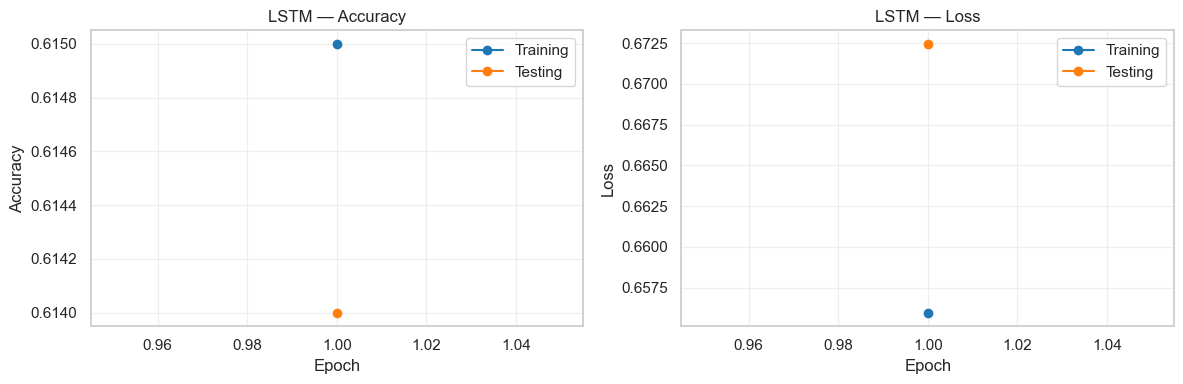

In [74]:
lstm_x = list(range(1, len(lstm_history['train_acc']) + 1))
plot_acc_loss_curves(
    'LSTM', lstm_x,
    {'train': lstm_history['train_acc'],  'test': lstm_history['test_acc']},
    {'train': lstm_history['train_loss'], 'test': lstm_history['test_loss']},
    xlabel='Epoch',
)

### 7.6 Test Evaluation

In [75]:
def lstm_predict(X_t, batch_size=256):
    lstm_model.train(False)
    all_probs = []
    with torch.no_grad():
        for i in range(0, X_t.shape[0], batch_size):
            chunk = X_t[i:i + batch_size].to(DEVICE)
            logits = lstm_model(chunk)
            all_probs.append(torch.sigmoid(logits).cpu().numpy())
    probs = np.concatenate(all_probs)
    return probs, (probs >= 0.5).astype(int)

lstm_train_probs, y_pred_lstm_train = lstm_predict(X_train_seq_t)
lstm_test_probs,  y_pred_lstm       = lstm_predict(X_test_seq_t)

lstm_metrics = {
    'Model':     'LSTM',
    'TrainAcc':  accuracy_score(y_train, y_pred_lstm_train),
    'TestAcc':   accuracy_score(y_test,  y_pred_lstm),
    'F1':        f1_score(y_test,         y_pred_lstm),
    'Precision': precision_score(y_test,  y_pred_lstm),
    'Recall':    recall_score(y_test,     y_pred_lstm),
    'ROC-AUC':   roc_auc_score(y_test,    lstm_test_probs),
}

print('=== LSTM ===')
print(f'Train acc: {lstm_metrics["TrainAcc"]:.4f}  |  Test acc: {lstm_metrics["TestAcc"]:.4f}')
print(f'Test F1: {lstm_metrics["F1"]:.4f}  Precision: {lstm_metrics["Precision"]:.4f}  Recall: {lstm_metrics["Recall"]:.4f}  ROC-AUC: {lstm_metrics["ROC-AUC"]:.4f}')
print()
print(classification_report(y_test, y_pred_lstm, target_names=['Real', 'Fake']))

=== LSTM ===
Train acc: 0.6150  |  Test acc: 0.6140
Test F1: 0.2930  Precision: 0.8333  Recall: 0.1778  ROC-AUC: 0.6305

              precision    recall  f1-score   support

        Real       0.59      0.97      0.73       275
        Fake       0.83      0.18      0.29       225

    accuracy                           0.61       500
   macro avg       0.71      0.57      0.51       500
weighted avg       0.70      0.61      0.54       500



### 7.7 GRU Classifier

Bidirectional GRU (Cho et al., 2014) - a lighter gated alternative to LSTM
with one gate fewer. Same training pipeline, useful as a direct comparison
of gating mechanisms on the same tokenised inputs.

In [76]:
class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=LSTM_EMBED_DIM,
                 hidden_dim=LSTM_HIDDEN_DIM, num_layers=1, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        emb = self.embedding(x)
        _, h = self.gru(emb)
        h = h.view(self.gru.num_layers, 2, x.size(0), self.gru.hidden_size)
        last = h[-1]
        pooled = torch.cat([last[0], last[1]], dim=1)
        return self.fc(self.dropout(pooled)).squeeze(1)

gru_model    = GRUClassifier(LSTM_VOCAB_SIZE).to(DEVICE)
gru_optim    = torch.optim.Adam(gru_model.parameters(), lr=LSTM_LR)
gru_loss_fn  = nn.BCEWithLogitsLoss()
print(gru_model)
print(f'Trainable parameters: {sum(p.numel() for p in gru_model.parameters()):,}')

gru_history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

def gru_loader_metrics(loader):
    gru_model.train(False)
    tl, c, n = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = gru_model(xb)
            tl += gru_loss_fn(logits, yb).item() * yb.size(0)
            preds = (torch.sigmoid(logits) >= 0.5).float()
            c += (preds == yb).sum().item(); n += yb.size(0)
    return tl / n, c / n

for epoch in range(1, LSTM_EPOCHS + 1):
    gru_model.train(True)
    for xb, yb in lstm_tr_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        gru_optim.zero_grad()
        loss = gru_loss_fn(gru_model(xb), yb)
        loss.backward()
        gru_optim.step()
    tr_l, tr_a = gru_loader_metrics(lstm_tr_loader)
    te_l, te_a = gru_loader_metrics(lstm_te_loader)
    gru_history['train_loss'].append(tr_l); gru_history['train_acc'].append(tr_a)
    gru_history['test_loss'].append(te_l);  gru_history['test_acc'].append(te_a)
    print(f'Epoch {epoch:02d} | train loss {tr_l:.4f} acc {tr_a:.4f} '
          f'| test loss {te_l:.4f} acc {te_a:.4f}')

def gru_predict(X_t, batch_size=256):
    gru_model.train(False)
    out = []
    with torch.no_grad():
        for i in range(0, X_t.shape[0], batch_size):
            chunk = X_t[i:i + batch_size].to(DEVICE)
            out.append(torch.sigmoid(gru_model(chunk)).cpu().numpy())
    probs = np.concatenate(out)
    return probs, (probs >= 0.5).astype(int)

gru_train_probs, y_pred_gru_train = gru_predict(X_train_seq_t)
gru_test_probs,  y_pred_gru       = gru_predict(X_test_seq_t)

gru_metrics = {
    'Model':     'GRU',
    'TrainAcc':  accuracy_score(y_train, y_pred_gru_train),
    'TestAcc':   accuracy_score(y_test,  y_pred_gru),
    'F1':        f1_score(y_test,         y_pred_gru),
    'Precision': precision_score(y_test,  y_pred_gru),
    'Recall':    recall_score(y_test,     y_pred_gru),
    'ROC-AUC':   roc_auc_score(y_test,    gru_test_probs),
}
print('=== GRU ===')
print(f'Test acc: {gru_metrics["TestAcc"]:.4f}  F1: {gru_metrics["F1"]:.4f}  ROC-AUC: {gru_metrics["ROC-AUC"]:.4f}')
print(classification_report(y_test, y_pred_gru, target_names=['Real', 'Fake']))

GRUClassifier(
  (embedding): Embedding(17042, 64, padding_idx=0)
  (gru): GRU(64, 64, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)
Trainable parameters: 1,140,737
Epoch 01 | train loss 0.6438 acc 0.6450 | test loss 0.6627 acc 0.6080
=== GRU ===
Test acc: 0.6080  F1: 0.3875  ROC-AUC: 0.6464
              precision    recall  f1-score   support

        Real       0.60      0.88      0.71       275
        Fake       0.65      0.28      0.39       225

    accuracy                           0.61       500
   macro avg       0.63      0.58      0.55       500
weighted avg       0.62      0.61      0.57       500



### 7.8 TextCNN (FNDNet-inspired)

1D convolutional text classifier (Kim, 2014; Kaliyar et al., 2020 "FNDNet").
Three parallel convolution branches with kernel sizes 3 / 4 / 5 capture
n-gram-like patterns over the word embeddings; their channel-wise max-pools
are concatenated, dropped out, and passed to a linear head. Often trains
faster than the recurrent variants and is competitive on fake-news tasks.

In [77]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=LSTM_EMBED_DIM,
                 num_filters=64, kernel_sizes=(3, 4, 5), dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k, padding=k // 2)
            for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), 1)

    def forward(self, x):
        emb = self.embedding(x).transpose(1, 2)
        feats = [F.relu(conv(emb)).max(dim=2).values for conv in self.convs]
        h = torch.cat(feats, dim=1)
        return self.fc(self.dropout(h)).squeeze(1)

cnn_model    = TextCNN(LSTM_VOCAB_SIZE).to(DEVICE)
cnn_optim    = torch.optim.Adam(cnn_model.parameters(), lr=LSTM_LR)
cnn_loss_fn  = nn.BCEWithLogitsLoss()
print(cnn_model)
print(f'Trainable parameters: {sum(p.numel() for p in cnn_model.parameters()):,}')

cnn_history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

def cnn_loader_metrics(loader):
    cnn_model.train(False)
    tl, c, n = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = cnn_model(xb)
            tl += cnn_loss_fn(logits, yb).item() * yb.size(0)
            preds = (torch.sigmoid(logits) >= 0.5).float()
            c += (preds == yb).sum().item(); n += yb.size(0)
    return tl / n, c / n

for epoch in range(1, LSTM_EPOCHS + 1):
    cnn_model.train(True)
    for xb, yb in lstm_tr_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        cnn_optim.zero_grad()
        loss = cnn_loss_fn(cnn_model(xb), yb)
        loss.backward()
        cnn_optim.step()
    tr_l, tr_a = cnn_loader_metrics(lstm_tr_loader)
    te_l, te_a = cnn_loader_metrics(lstm_te_loader)
    cnn_history['train_loss'].append(tr_l); cnn_history['train_acc'].append(tr_a)
    cnn_history['test_loss'].append(te_l);  cnn_history['test_acc'].append(te_a)
    print(f'Epoch {epoch:02d} | train loss {tr_l:.4f} acc {tr_a:.4f} '
          f'| test loss {te_l:.4f} acc {te_a:.4f}')

def cnn_predict(X_t, batch_size=256):
    cnn_model.train(False)
    out = []
    with torch.no_grad():
        for i in range(0, X_t.shape[0], batch_size):
            chunk = X_t[i:i + batch_size].to(DEVICE)
            out.append(torch.sigmoid(cnn_model(chunk)).cpu().numpy())
    probs = np.concatenate(out)
    return probs, (probs >= 0.5).astype(int)

cnn_train_probs, y_pred_cnn_train = cnn_predict(X_train_seq_t)
cnn_test_probs,  y_pred_cnn       = cnn_predict(X_test_seq_t)

cnn_metrics = {
    'Model':     'TextCNN',
    'TrainAcc':  accuracy_score(y_train, y_pred_cnn_train),
    'TestAcc':   accuracy_score(y_test,  y_pred_cnn),
    'F1':        f1_score(y_test,         y_pred_cnn),
    'Precision': precision_score(y_test,  y_pred_cnn),
    'Recall':    recall_score(y_test,     y_pred_cnn),
    'ROC-AUC':   roc_auc_score(y_test,    cnn_test_probs),
}
print('=== TextCNN ===')
print(f'Test acc: {cnn_metrics["TestAcc"]:.4f}  F1: {cnn_metrics["F1"]:.4f}  ROC-AUC: {cnn_metrics["ROC-AUC"]:.4f}')
print(classification_report(y_test, y_pred_cnn, target_names=['Real', 'Fake']))

TextCNN(
  (embedding): Embedding(17042, 64, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): Conv1d(64, 64, kernel_size=(4,), stride=(1,), padding=(2,))
    (2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=192, out_features=1, bias=True)
)
Trainable parameters: 1,140,225
Epoch 01 | train loss 0.5234 acc 0.7880 | test loss 0.5692 acc 0.7500
=== TextCNN ===
Test acc: 0.7500  F1: 0.6612  ROC-AUC: 0.8874
              precision    recall  f1-score   support

        Real       0.71      0.92      0.80       275
        Fake       0.85      0.54      0.66       225

    accuracy                           0.75       500
   macro avg       0.78      0.73      0.73       500
weighted avg       0.77      0.75      0.74       500



### 7.9 BiLSTM with Additive Attention

A bidirectional LSTM whose per-timestep outputs are pooled by a learned
additive attention mechanism (Bahdanau-style, applied at the token level -
cf. Mohapatra et al., 2022 "Attention-based C-BiLSTM for fake news
detection"). Attention masking ignores `<pad>` tokens.

In [78]:
class BiLSTMAttn(nn.Module):
    def __init__(self, vocab_size, embed_dim=LSTM_EMBED_DIM,
                 hidden_dim=LSTM_HIDDEN_DIM, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embed_dim, hidden_size=hidden_dim,
            batch_first=True, bidirectional=True,
        )
        self.attn = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        mask = (x != 0).float().unsqueeze(-1)
        emb = self.embedding(x)
        out, _ = self.lstm(emb)
        scores = self.attn(out)
        scores = scores.masked_fill(mask == 0, float('-inf'))
        weights = torch.softmax(scores, dim=1)
        ctx = (out * weights).sum(dim=1)
        return self.fc(self.dropout(ctx)).squeeze(1)

attn_model    = BiLSTMAttn(LSTM_VOCAB_SIZE).to(DEVICE)
attn_optim    = torch.optim.Adam(attn_model.parameters(), lr=LSTM_LR)
attn_loss_fn  = nn.BCEWithLogitsLoss()
print(attn_model)
print(f'Trainable parameters: {sum(p.numel() for p in attn_model.parameters()):,}')

attn_history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

def attn_loader_metrics(loader):
    attn_model.train(False)
    tl, c, n = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = attn_model(xb)
            tl += attn_loss_fn(logits, yb).item() * yb.size(0)
            preds = (torch.sigmoid(logits) >= 0.5).float()
            c += (preds == yb).sum().item(); n += yb.size(0)
    return tl / n, c / n

for epoch in range(1, LSTM_EPOCHS + 1):
    attn_model.train(True)
    for xb, yb in lstm_tr_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        attn_optim.zero_grad()
        loss = attn_loss_fn(attn_model(xb), yb)
        loss.backward()
        attn_optim.step()
    tr_l, tr_a = attn_loader_metrics(lstm_tr_loader)
    te_l, te_a = attn_loader_metrics(lstm_te_loader)
    attn_history['train_loss'].append(tr_l); attn_history['train_acc'].append(tr_a)
    attn_history['test_loss'].append(te_l);  attn_history['test_acc'].append(te_a)
    print(f'Epoch {epoch:02d} | train loss {tr_l:.4f} acc {tr_a:.4f} '
          f'| test loss {te_l:.4f} acc {te_a:.4f}')

def attn_predict(X_t, batch_size=256):
    attn_model.train(False)
    out = []
    with torch.no_grad():
        for i in range(0, X_t.shape[0], batch_size):
            chunk = X_t[i:i + batch_size].to(DEVICE)
            out.append(torch.sigmoid(attn_model(chunk)).cpu().numpy())
    probs = np.concatenate(out)
    return probs, (probs >= 0.5).astype(int)

attn_train_probs, y_pred_attn_train = attn_predict(X_train_seq_t)
attn_test_probs,  y_pred_attn       = attn_predict(X_test_seq_t)

attn_metrics = {
    'Model':     'BiLSTM+Attn',
    'TrainAcc':  accuracy_score(y_train, y_pred_attn_train),
    'TestAcc':   accuracy_score(y_test,  y_pred_attn),
    'F1':        f1_score(y_test,         y_pred_attn),
    'Precision': precision_score(y_test,  y_pred_attn),
    'Recall':    recall_score(y_test,     y_pred_attn),
    'ROC-AUC':   roc_auc_score(y_test,    attn_test_probs),
}
print('=== BiLSTM+Attn ===')
print(f'Test acc: {attn_metrics["TestAcc"]:.4f}  F1: {attn_metrics["F1"]:.4f}  ROC-AUC: {attn_metrics["ROC-AUC"]:.4f}')
print(classification_report(y_test, y_pred_attn, target_names=['Real', 'Fake']))

BiLSTMAttn(
  (embedding): Embedding(17042, 64, padding_idx=0)
  (lstm): LSTM(64, 64, batch_first=True, bidirectional=True)
  (attn): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)
Trainable parameters: 1,157,506
Epoch 01 | train loss 0.6266 acc 0.6310 | test loss 0.6251 acc 0.6860
=== BiLSTM+Attn ===
Test acc: 0.6860  F1: 0.5449  ROC-AUC: 0.8146
              precision    recall  f1-score   support

        Real       0.66      0.91      0.76       275
        Fake       0.78      0.42      0.54       225

    accuracy                           0.69       500
   macro avg       0.72      0.66      0.65       500
weighted avg       0.71      0.69      0.66       500



## 8. Transformer Approach: PyTorch + DistilBERT

### 8.1 Rationale

Full BERT fine-tuning is expensive on CPU (multiple hours per epoch on this dataset) and still costly on consumer-grade GPUs. To keep the notebook portable across hardware, this section uses **DistilBERT** - a distilled variant of BERT with ~40% fewer parameters and ~60% faster inference - and treats it as a **frozen feature extractor**:

1. Each article is tokenized and passed through DistilBERT once.
2. The hidden state of the `[CLS]` token is taken as a 768-dimensional sentence embedding.
3. A small PyTorch MLP head is trained on top of these embeddings.

Unlike the LSTM in Section 7, the DistilBERT encoder is **not trained** here - it provides pre-learned contextual representations that the head then maps to the binary label. This is the standard frozen-encoder transfer-learning pattern. It is also hardware-agnostic: on a GPU the embedding pass and head training are both several times faster, but the workload remains feasible on CPU because the encoder is never updated.

In [79]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN    = 128

if DEVICE.type == 'cuda':
    BATCH_SIZE = 256
    USE_FP16   = True
else:
    BATCH_SIZE = 32
    USE_FP16   = False

# Optional subsampling for faster execution.
# In SMOKE_TEST mode the train/test splits are already subsampled in section 5.6,
# so we just encode all of them here (SAMPLE_SIZE=None).
SAMPLE_SIZE = None

print(f'BERT batch size: {BATCH_SIZE}  |  FP16: {USE_FP16}')

BERT batch size: 32  |  FP16: False


### 8.2 Tokenizer and Encoder Setup

The encoder is loaded once, switched to inference mode, and all of its parameters are frozen - only the small classifier head defined below will be trained.

In [80]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
encoder   = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
encoder.train(False)  # switch to inference mode
for p in encoder.parameters():
    p.requires_grad = False

total_params = sum(p.numel() for p in encoder.parameters())
print(f'Encoder parameters: {total_params:,}')

Encoder parameters: 66,362,880


### 8.3 Embedding Extraction

Embedding extraction is a forward pass under `torch.no_grad()`. For each article, the `[CLS]` token's last hidden state is taken as a 768-dimensional summary vector.

In [81]:
def embed_texts(texts, batch_size=BATCH_SIZE):
    embeddings = []
    n = len(texts)
    for start in range(0, n, batch_size):
        batch = list(texts[start:start + batch_size])
        enc = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=MAX_LEN,
            return_tensors='pt',
        ).to(DEVICE)
        with torch.no_grad():
            if USE_FP16:
                with torch.autocast(device_type=DEVICE.type, dtype=torch.float16):
                    outputs = encoder(**enc)
            else:
                outputs = encoder(**enc)
        # Cast back to float32 for stable storage on host RAM.
        cls_vec = outputs.last_hidden_state[:, 0, :].float()
        embeddings.append(cls_vec.cpu())
        if (start // batch_size) % 50 == 0:
            print(f'  ... {min(start + batch_size, n):,}/{n:,}')
    return torch.cat(embeddings, dim=0)

In [82]:
if SAMPLE_SIZE is not None:
    rng = np.random.default_rng(RANDOM_STATE)
    n_test_target = max(1, SAMPLE_SIZE * 20 // 80)
    tr_sel = rng.choice(len(X_train_raw), size=min(SAMPLE_SIZE,    len(X_train_raw)), replace=False)
    te_sel = rng.choice(len(X_test_raw),  size=min(n_test_target,  len(X_test_raw)),  replace=False)
    train_texts = X_train_raw[tr_sel];  y_train_dl = y_train[tr_sel]
    test_texts  = X_test_raw[te_sel];   y_test_dl  = y_test[te_sel]
else:
    train_texts, y_train_dl = X_train_raw, y_train
    test_texts,  y_test_dl  = X_test_raw,  y_test

print(f'Embedding {len(train_texts):,} training articles...')
X_train_emb = embed_texts(train_texts)
print(f'Embedding {len(test_texts):,} test articles...')
X_test_emb  = embed_texts(test_texts)

print(f'Train embeddings: {tuple(X_train_emb.shape)}')
print(f'Test  embeddings: {tuple(X_test_emb.shape)}')

Embedding 2,000 training articles...
  ... 32/2,000
  ... 1,632/2,000
Embedding 500 test articles...
  ... 32/500
Train embeddings: (2000, 768)
Test  embeddings: (500, 768)


### 8.4 Classifier Head

A two-layer MLP is trained on the frozen embeddings:

```
Linear(768 -> 128) -> ReLU -> Dropout(0.2) -> Linear(128 -> 1)
```

The output is a single logit; `BCEWithLogitsLoss` combines a sigmoid and binary cross-entropy in a numerically stable way.

In [83]:
class ClassifierHead(nn.Module):
    def __init__(self, in_dim: int = 768, hidden: int = 128, dropout: float = 0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x)

head = ClassifierHead(in_dim=X_train_emb.shape[1]).to(DEVICE)
optimizer = torch.optim.Adam(head.parameters(), lr=1e-3)
loss_fn   = nn.BCEWithLogitsLoss()
print(head)

ClassifierHead(
  (net): Sequential(
    (0): Linear(in_features=768, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)


### 8.5 Training Loop

The MLP head is trained on the **80 %** training embeddings for a fixed number of epochs. Because the 80/20 split leaves no separate validation set, there is no early stopping - the model trains for `EPOCHS` epochs and the final weights are kept. The test set is plotted alongside training purely as a per-epoch diagnostic; it is **never used to update the model** or select an epoch.

In [84]:
y_train_t = torch.tensor(y_train_dl, dtype=torch.float32)
y_test_t  = torch.tensor(y_test_dl,  dtype=torch.float32)

tr_loader   = DataLoader(TensorDataset(X_train_emb, y_train_t), batch_size=64,  shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_emb,  y_test_t),  batch_size=256, shuffle=False)

def epoch_metrics(loader):
    head.train(False)
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE); yb = yb.to(DEVICE)
            logits = head(xb).squeeze(1)
            total_loss += loss_fn(logits, yb).item() * xb.size(0)
            preds = (torch.sigmoid(logits) >= 0.5).float()
            correct += (preds == yb).sum().item()
            total += xb.size(0)
    return total_loss / total, correct / total

EPOCHS = 5
# Test metrics are tracked PER EPOCH purely for the diagnostic curve
# in the next cell; they are NOT used to select the model.
history = {
    'train_loss': [], 'test_loss': [],
    'train_acc':  [], 'test_acc':  [],
}

for epoch in range(1, EPOCHS + 1):
    head.train(True)
    for xb, yb in tr_loader:
        xb = xb.to(DEVICE); yb = yb.to(DEVICE)
        optimizer.zero_grad()
        logits = head(xb).squeeze(1)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()

    tr_loss,   tr_acc   = epoch_metrics(tr_loader)
    test_loss, test_acc = epoch_metrics(test_loader)
    history['train_loss'].append(tr_loss);   history['train_acc'].append(tr_acc)
    history['test_loss'].append(test_loss);  history['test_acc'].append(test_acc)
    print(f'Epoch {epoch:02d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} '
          f'| test loss {test_loss:.4f} acc {test_acc:.4f}')

Epoch 01 | train loss 0.4066 acc 0.8235 | test loss 0.4152 acc 0.8200
Epoch 02 | train loss 0.3254 acc 0.8680 | test loss 0.3465 acc 0.8380
Epoch 03 | train loss 0.2855 acc 0.8850 | test loss 0.3059 acc 0.8640
Epoch 04 | train loss 0.2623 acc 0.8925 | test loss 0.2783 acc 0.8800
Epoch 05 | train loss 0.2438 acc 0.9015 | test loss 0.2631 acc 0.8880


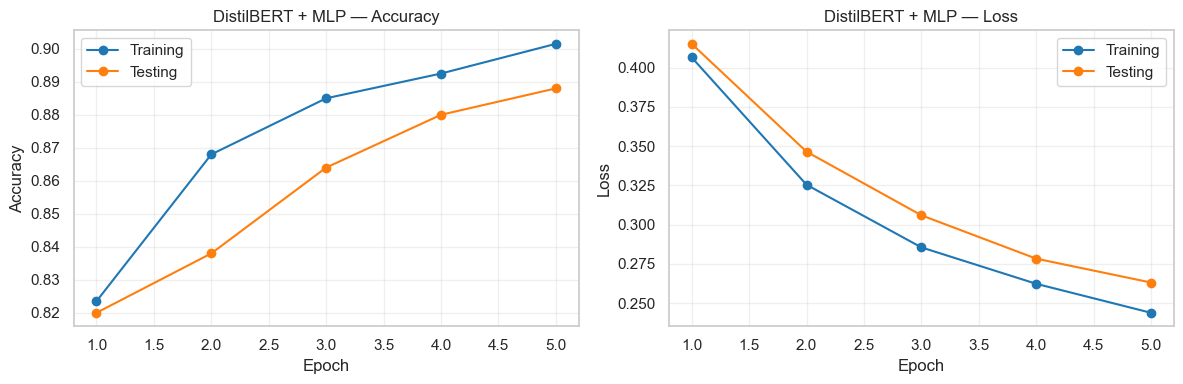

In [85]:
x = list(range(1, len(history['train_acc']) + 1))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(x, history['train_acc'], '-o', label='Training', color='#1f77b4')
axes[0].plot(x, history['test_acc'],  '-o', label='Testing',  color='#ff7f0e')
axes[0].set_title('DistilBERT + MLP \u2014 Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(x, history['train_loss'], '-o', label='Training', color='#1f77b4')
axes[1].plot(x, history['test_loss'],  '-o', label='Testing',  color='#ff7f0e')
axes[1].set_title('DistilBERT + MLP \u2014 Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 8.6 Test-Set Evaluation

In [86]:
def bert_predict(emb, batch_size=256):
    """Predict in batches so we don't shove the whole tensor onto GPU at once."""
    head.train(False)
    all_probs = []
    with torch.no_grad():
        for i in range(0, emb.shape[0], batch_size):
            chunk = emb[i:i + batch_size].to(DEVICE)
            logits = head(chunk).squeeze(1)
            all_probs.append(torch.sigmoid(logits).cpu().numpy())
    probs = np.concatenate(all_probs)
    return probs, (probs >= 0.5).astype(int)

train_probs, y_pred_bert_train = bert_predict(X_train_emb)
test_probs,  y_pred_bert       = bert_predict(X_test_emb)

bert_metrics = {
    'Model':     'DistilBERT + MLP',
    'TrainAcc':  accuracy_score(y_train_dl, y_pred_bert_train),
    'TestAcc':   accuracy_score(y_test_dl,  y_pred_bert),
    'F1':        f1_score(y_test_dl,        y_pred_bert),
    'Precision': precision_score(y_test_dl, y_pred_bert),
    'Recall':    recall_score(y_test_dl,    y_pred_bert),
    'ROC-AUC':   roc_auc_score(y_test_dl,   test_probs),
}

print('=== DistilBERT + MLP ===')
print(f'Train acc: {bert_metrics["TrainAcc"]:.4f}  |  Test acc: {bert_metrics["TestAcc"]:.4f}')
print(f'Test F1: {bert_metrics["F1"]:.4f}  Precision: {bert_metrics["Precision"]:.4f}  Recall: {bert_metrics["Recall"]:.4f}  ROC-AUC: {bert_metrics["ROC-AUC"]:.4f}')
print()
print(classification_report(y_test_dl, y_pred_bert, target_names=['Real', 'Fake']))

# Legacy aliases used by downstream cells.
bert_f1  = bert_metrics['F1']
bert_acc = bert_metrics['TestAcc']

=== DistilBERT + MLP ===
Train acc: 0.9015  |  Test acc: 0.8880
Test F1: 0.8739  Precision: 0.8858  Recall: 0.8622  ROC-AUC: 0.9595

              precision    recall  f1-score   support

        Real       0.89      0.91      0.90       275
        Fake       0.89      0.86      0.87       225

    accuracy                           0.89       500
   macro avg       0.89      0.89      0.89       500
weighted avg       0.89      0.89      0.89       500



### 8.7 RoBERTa Frozen Embeddings + MLP Head

`roberta-base` is run as a second frozen encoder, mirroring the DistilBERT
pipeline. RoBERTa drops the next-sentence-prediction objective from BERT and
trains on substantially more data; on the WELFake dataset multiple
comparison studies (e.g., the WELFake benchmark and Nature *Sci. Rep.* 2024
"Ensemble based high performance deep learning models for fake news
detection") report it as the strongest single transformer.

The `<s>` (CLS) token's last hidden state is used as a 768-dimensional
document embedding; a small MLP head is trained on top.

In [87]:
ROBERTA_NAME = 'roberta-base'

rob_tokenizer = AutoTokenizer.from_pretrained(ROBERTA_NAME)
rob_encoder   = AutoModel.from_pretrained(ROBERTA_NAME).to(DEVICE)
rob_encoder.train(False)
for p in rob_encoder.parameters():
    p.requires_grad = False
print(f'RoBERTa parameters: {sum(p.numel() for p in rob_encoder.parameters()):,}')

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

c:\Users\Admin\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Admin\.cache\huggingface\hub\models--roberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RoBERTa parameters: 124,645,632


In [88]:
def embed_texts_roberta(texts, batch_size=BATCH_SIZE):
    embeddings = []
    n = len(texts)
    for start in range(0, n, batch_size):
        batch = list(texts[start:start + batch_size])
        enc = rob_tokenizer(
            batch, padding=True, truncation=True,
            max_length=MAX_LEN, return_tensors='pt',
        ).to(DEVICE)
        with torch.no_grad():
            if USE_FP16:
                with torch.autocast(device_type=DEVICE.type, dtype=torch.float16):
                    outputs = rob_encoder(**enc)
            else:
                outputs = rob_encoder(**enc)
        cls_vec = outputs.last_hidden_state[:, 0, :].float()
        embeddings.append(cls_vec.cpu())
        if (start // batch_size) % 50 == 0:
            print(f'  ... {min(start + batch_size, n):,}/{n:,}')
    return torch.cat(embeddings, dim=0)

print(f'Embedding {len(train_texts):,} training articles (RoBERTa)...')
X_train_emb_rob = embed_texts_roberta(train_texts)
print(f'Embedding {len(test_texts):,} test articles (RoBERTa)...')
X_test_emb_rob  = embed_texts_roberta(test_texts)
print(f'Train embeddings: {tuple(X_train_emb_rob.shape)}')
print(f'Test  embeddings: {tuple(X_test_emb_rob.shape)}')

Embedding 2,000 training articles (RoBERTa)...
  ... 32/2,000
  ... 1,632/2,000
Embedding 500 test articles (RoBERTa)...
  ... 32/500
Train embeddings: (2000, 768)
Test  embeddings: (500, 768)


In [89]:
rob_head = ClassifierHead(in_dim=X_train_emb_rob.shape[1]).to(DEVICE)
rob_optimizer = torch.optim.Adam(rob_head.parameters(), lr=1e-3)
rob_loss_fn   = nn.BCEWithLogitsLoss()
print(rob_head)

ClassifierHead(
  (net): Sequential(
    (0): Linear(in_features=768, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)


In [90]:
rob_tr_loader   = DataLoader(TensorDataset(X_train_emb_rob, y_train_t), batch_size=64,  shuffle=True)
rob_test_loader = DataLoader(TensorDataset(X_test_emb_rob,  y_test_t),  batch_size=256, shuffle=False)

def rob_epoch_metrics(loader):
    rob_head.train(False)
    tl, c, n = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = rob_head(xb).squeeze(1)
            tl += rob_loss_fn(logits, yb).item() * xb.size(0)
            preds = (torch.sigmoid(logits) >= 0.5).float()
            c += (preds == yb).sum().item(); n += xb.size(0)
    return tl / n, c / n

ROB_EPOCHS = 2 if SMOKE_TEST else 5
rob_history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(1, ROB_EPOCHS + 1):
    rob_head.train(True)
    for xb, yb in rob_tr_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        rob_optimizer.zero_grad()
        loss = rob_loss_fn(rob_head(xb).squeeze(1), yb)
        loss.backward()
        rob_optimizer.step()
    tr_l, tr_a = rob_epoch_metrics(rob_tr_loader)
    te_l, te_a = rob_epoch_metrics(rob_test_loader)
    rob_history['train_loss'].append(tr_l); rob_history['train_acc'].append(tr_a)
    rob_history['test_loss'].append(te_l);  rob_history['test_acc'].append(te_a)
    print(f'Epoch {epoch:02d} | train loss {tr_l:.4f} acc {tr_a:.4f} '
          f'| test loss {te_l:.4f} acc {te_a:.4f}')

Epoch 01 | train loss 0.5662 acc 0.6720 | test loss 0.5652 acc 0.6800
Epoch 02 | train loss 0.3766 acc 0.9090 | test loss 0.3742 acc 0.9060


In [91]:
def roberta_predict(emb, batch_size=256):
    rob_head.train(False)
    out = []
    with torch.no_grad():
        for i in range(0, emb.shape[0], batch_size):
            chunk = emb[i:i + batch_size].to(DEVICE)
            logits = rob_head(chunk).squeeze(1)
            out.append(torch.sigmoid(logits).cpu().numpy())
    probs = np.concatenate(out)
    return probs, (probs >= 0.5).astype(int)

rob_train_probs, y_pred_rob_train = roberta_predict(X_train_emb_rob)
rob_test_probs,  y_pred_rob       = roberta_predict(X_test_emb_rob)

roberta_metrics = {
    'Model':     'RoBERTa + MLP',
    'TrainAcc':  accuracy_score(y_train_dl, y_pred_rob_train),
    'TestAcc':   accuracy_score(y_test_dl,  y_pred_rob),
    'F1':        f1_score(y_test_dl,        y_pred_rob),
    'Precision': precision_score(y_test_dl, y_pred_rob),
    'Recall':    recall_score(y_test_dl,    y_pred_rob),
    'ROC-AUC':   roc_auc_score(y_test_dl,   rob_test_probs),
}
print('=== RoBERTa + MLP ===')
print(f'Test acc: {roberta_metrics["TestAcc"]:.4f}  F1: {roberta_metrics["F1"]:.4f}  ROC-AUC: {roberta_metrics["ROC-AUC"]:.4f}')
print(classification_report(y_test_dl, y_pred_rob, target_names=['Real', 'Fake']))

=== RoBERTa + MLP ===
Test acc: 0.9060  F1: 0.8944  ROC-AUC: 0.9728
              precision    recall  f1-score   support

        Real       0.91      0.92      0.92       275
        Fake       0.90      0.88      0.89       225

    accuracy                           0.91       500
   macro avg       0.91      0.90      0.90       500
weighted avg       0.91      0.91      0.91       500



## 9. Results & Discussion

### 9.1 Combined Comparison

In [92]:
all_results = pd.concat([
    baseline_results,
    pd.DataFrame([
        lstm_metrics, gru_metrics, cnn_metrics, attn_metrics,
        bert_metrics, roberta_metrics,
    ])[
        ['Model', 'TrainAcc', 'TestAcc', 'F1', 'Precision', 'Recall', 'ROC-AUC']
    ],
], ignore_index=True).round(4)
all_results.sort_values('F1', ascending=False, ignore_index=True)

,Model,TrainAcc,TestAcc,F1,Precision,Recall,ROC-AUC
0,Stacking (LR+SVM+LGBM),1.0000,0.942,0.9357,0.9336,0.9378,0.9826
1,LightGBM,0.9995,0.930,0.9237,0.9060,0.9422,0.9731
2,XGBoost,0.9900,0.922,0.9150,0.8974,0.9333,0.9754
3,RoBERTa + MLP,0.9090,0.906,0.8944,0.9045,0.8844,0.9728
4,Linear SVM,0.9865,0.902,0.8918,0.8860,0.8978,0.9653
5,Logistic Regression,0.9570,0.888,0.8750,0.8789,0.8711,0.9590
6,Random Forest,1.0000,0.888,0.8739,0.8858,0.8622,0.9520
7,DistilBERT + MLP,0.9015,0.888,0.8739,0.8858,0.8622,0.9595
8,Naive Bayes,0.8955,0.836,0.8145,0.8295,0.8000,0.9126
9,TextCNN,0.7880,0.750,0.6612,0.8472,0.5422,0.8874


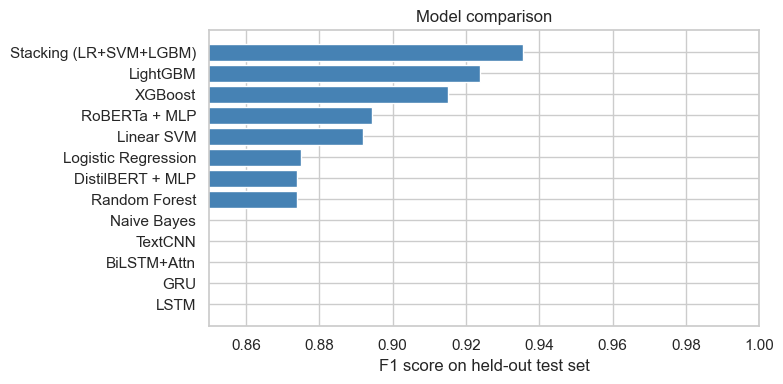

In [93]:
plt.figure(figsize=(8, 4))
sorted_res = all_results.sort_values('F1', ascending=True)
plt.barh(sorted_res['Model'], sorted_res['F1'], color='steelblue')
plt.xlabel('F1 score on held-out test set')
plt.title('Model comparison')
plt.xlim(0.85, 1.0)
plt.tight_layout()
plt.show()

### 9.2 Confusion Matrices

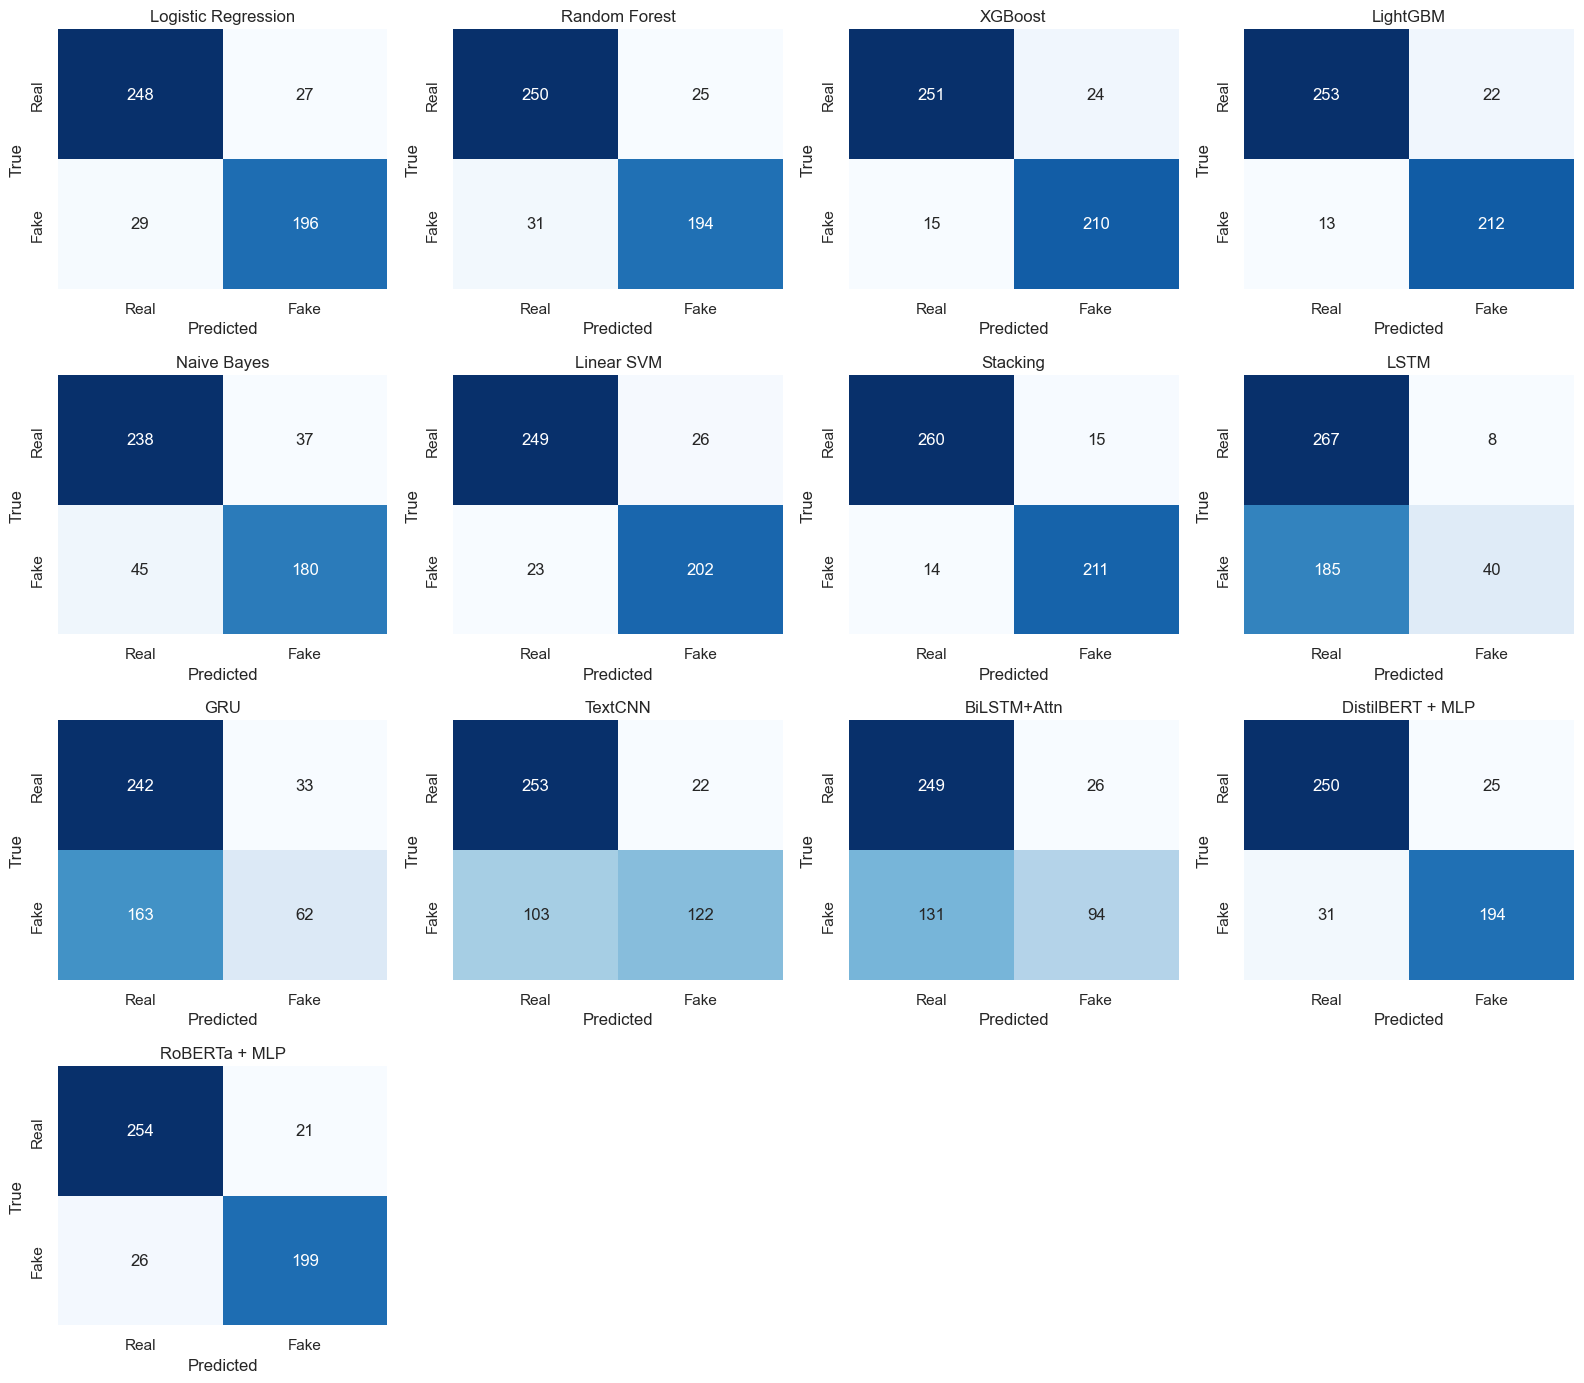

In [94]:
preds_for_cm = {
    'Logistic Regression':  (y_test,    y_pred_lr),
    'Random Forest':        (y_test,    y_pred_rf),
    'XGBoost':              (y_test,    y_pred_xgb),
    'LightGBM':             (y_test,    y_pred_lgbm),
    'Naive Bayes':          (y_test,    y_pred_nb),
    'Linear SVM':           (y_test,    y_pred_svm),
    'Stacking':             (y_test,    y_pred_stk),
    'LSTM':                 (y_test,    y_pred_lstm),
    'GRU':                  (y_test,    y_pred_gru),
    'TextCNN':              (y_test,    y_pred_cnn),
    'BiLSTM+Attn':          (y_test,    y_pred_attn),
    'DistilBERT + MLP':     (y_test_dl, y_pred_bert),
    'RoBERTa + MLP':        (y_test_dl, y_pred_rob),
}
n_models_cm = len(preds_for_cm)
ncols = 4
nrows = (n_models_cm + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
for ax, (name, (yt, yp)) in zip(axes.flat, preds_for_cm.items()):
    sns.heatmap(
        confusion_matrix(yt, yp), annot=True, fmt='d', cmap='Blues',
        xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'], ax=ax, cbar=False,
    )
    ax.set_title(name); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
for ax in list(axes.flat)[n_models_cm:]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

### 9.3 Error Analysis

A small qualitative inspection of misclassified articles helps motivate future work.

In [95]:
mis_idx = np.where(y_pred_bert != y_test_dl)[0][:5]
for i in mis_idx:
    print(f'True: {y_test_dl[i]} | Predicted: {y_pred_bert[i]}')
    print(test_texts[i][:300].replace(chr(10), ' '))
    print('-' * 80)

True: 0 | Predicted: 1
Trump on Twitter (Aug 7): Fake News, Senator Richard Blumenthal The following statements were posted to the verified Twitter accounts of U.S. President Donald Trump, @realDonaldTrump and @POTUS.  The opinions expressed are his own. Reuters has not edited the statements or confirmed their accuracy.  
--------------------------------------------------------------------------------
True: 1 | Predicted: 0
WATCH LIBERAL CNN LAWYER Skewer “Village Idiot” Hillary Clinton: “Clear Violations Of Federal Records Act”  
--------------------------------------------------------------------------------
True: 0 | Predicted: 1
Archdiocese of Mexico City: Collaborators on Trump Wall ‘Traitors to their Country’ In a powerfully worded editorial, the Catholic archdiocese of Mexico City has condemned all companies and individuals who would work on Donald Trump’s border wall, calling them “immoral” and “traitors to their countr
----------------------------------------------------------

## 10. Saving the Best Model from Each Family

Every trained model is persisted to `models/` in a Hugging Face Hub-compatible
layout. The chosen formats are the current community-standard, signed-safe
serialisations:

| Family | Format | Library |
|--------|--------|---------|
| Classical (sklearn) | `model.skops` + `config.json` | `skops` |
| Sequence / Conv DL  | `model.safetensors` + `config.json` + `vocab.json` | `safetensors` + `torch` |
| Transformer + head  | encoder via `save_pretrained()` (HF native), head as `head.safetensors` + `config.json` | `transformers` + `safetensors` |

Each model folder is self-contained and can be pushed to the Hub later via
`huggingface_hub.HfApi().upload_folder(folder_path=..., repo_id=...)`.

An `overall_best.json` pointer is written at the top level to record which
model achieved the highest test F1 across all families.

In [96]:
from skops.io import dump as skops_dump
from safetensors.torch import save_file as safetensors_save

MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)

def _write_model_card(folder: Path, name: str, metrics: dict, extra: str = '') -> None:
    folder.mkdir(parents=True, exist_ok=True)
    card = f'''---
language: en
tags:
- fake-news
- text-classification
- welfake
license: apache-2.0
metrics:
- f1
- accuracy
- roc_auc
---

# {name}

Trained on the WELFake dataset for fake-news binary classification
(0 = real, 1 = fake).

## Test-set metrics

| Metric    | Value |
|-----------|-------|
| Accuracy  | {metrics["TestAcc"]:.4f} |
| F1        | {metrics["F1"]:.4f} |
| Precision | {metrics["Precision"]:.4f} |
| Recall    | {metrics["Recall"]:.4f} |
| ROC-AUC   | {metrics["ROC-AUC"]:.4f} |

{extra}
'''
    (folder / 'README.md').write_text(card, encoding='utf-8')


def _save_sklearn(folder: Path, model, metrics: dict, kind: str) -> None:
    folder.mkdir(parents=True, exist_ok=True)
    skops_dump(model, folder / 'model.skops')
    (folder / 'config.json').write_text(json.dumps({
        'kind': kind, 'sklearn_class': type(model).__name__,
        'metrics': metrics, 'feature_pipeline': 'tfidf',
    }, indent=2), encoding='utf-8')
    _write_model_card(folder, kind, metrics,
                      extra='## Load\n```python\nfrom skops.io import load\nmodel = load("model.skops", trusted=True)\n```\n')


def _save_torch(folder: Path, model: nn.Module, metrics: dict, kind: str,
                config: dict, vocab: dict | None = None) -> None:
    folder.mkdir(parents=True, exist_ok=True)
    safetensors_save({k: v.detach().cpu().contiguous() for k, v in model.state_dict().items()},
                     str(folder / 'model.safetensors'))
    (folder / 'config.json').write_text(json.dumps({
        'kind': kind, 'metrics': metrics, **config,
    }, indent=2), encoding='utf-8')
    if vocab is not None:
        (folder / 'vocab.json').write_text(json.dumps(vocab), encoding='utf-8')
    _write_model_card(folder, kind, metrics,
                      extra='## Load\n```python\nfrom safetensors.torch import load_file\nstate = load_file("model.safetensors")\nmodel.load_state_dict(state)\n```\n')


print('Saving classical models...')
tfidf_dir = MODELS_DIR / 'tfidf'
tfidf_dir.mkdir(exist_ok=True)
skops_dump(tfidf, tfidf_dir / 'tfidf.skops')
(tfidf_dir / 'config.json').write_text(json.dumps({'kind': 'TF-IDF vectorizer'}, indent=2))

classical_models = {
    'logistic_regression': (lr_model,       lr_metrics),
    'random_forest':       (rf_model,       rf_metrics),
    'xgboost':             (xgb_model,      xgb_metrics),
    'lightgbm':            (lgbm_model,     lgbm_metrics),
    'naive_bayes':         (nb_model,       nb_metrics),
    'linear_svm':          (svm_model,      svm_metrics),
    'stacking':            (stacking_model, stk_metrics),
}
for name, (m, met) in classical_models.items():
    _save_sklearn(MODELS_DIR / name, m, met, name)
    print(f'  ok  {name:<22}  F1={met["F1"]:.4f}')

print('Saving sequence / conv models...')
deep_models = {
    'lstm':         (lstm_model,  lstm_metrics, {'arch': 'BiLSTM',
                        'embed_dim': LSTM_EMBED_DIM, 'hidden_dim': LSTM_HIDDEN_DIM,
                        'max_len':   LSTM_MAX_LEN,   'vocab_size': LSTM_VOCAB_SIZE}),
    'gru':          (gru_model,   gru_metrics,  {'arch': 'BiGRU',
                        'embed_dim': LSTM_EMBED_DIM, 'hidden_dim': LSTM_HIDDEN_DIM,
                        'max_len':   LSTM_MAX_LEN,   'vocab_size': LSTM_VOCAB_SIZE}),
    'textcnn':      (cnn_model,   cnn_metrics,  {'arch': 'TextCNN',
                        'embed_dim': LSTM_EMBED_DIM, 'num_filters': 64,
                        'kernel_sizes': [3, 4, 5],
                        'max_len':   LSTM_MAX_LEN,   'vocab_size': LSTM_VOCAB_SIZE}),
    'bilstm_attn':  (attn_model,  attn_metrics, {'arch': 'BiLSTM+Attn',
                        'embed_dim': LSTM_EMBED_DIM, 'hidden_dim': LSTM_HIDDEN_DIM,
                        'max_len':   LSTM_MAX_LEN,   'vocab_size': LSTM_VOCAB_SIZE}),
}
for name, (m, met, cfg) in deep_models.items():
    _save_torch(MODELS_DIR / name, m, met, name, cfg, vocab=vocab)
    print(f'  ok  {name:<22}  F1={met["F1"]:.4f}')

print('Saving transformer models (encoder + head)...')
def _save_transformer(folder_name, encoder_obj, tokenizer_obj, head_obj, metrics, encoder_name):
    folder = MODELS_DIR / folder_name
    folder.mkdir(parents=True, exist_ok=True)
    enc_dir = folder / 'encoder'
    encoder_obj.save_pretrained(enc_dir)
    tokenizer_obj.save_pretrained(enc_dir)
    safetensors_save({k: v.detach().cpu().contiguous() for k, v in head_obj.state_dict().items()},
                     str(folder / 'head.safetensors'))
    (folder / 'config.json').write_text(json.dumps({
        'kind': folder_name, 'encoder_name': encoder_name,
        'head': {'in_dim': 768, 'hidden': 128, 'dropout': 0.2},
        'max_len': MAX_LEN, 'metrics': metrics,
    }, indent=2), encoding='utf-8')
    _write_model_card(folder, folder_name, metrics,
                      extra=f'## Encoder\n`{encoder_name}` (frozen).\n')

_save_transformer('distilbert_mlp', encoder,     tokenizer,     head,     bert_metrics,    MODEL_NAME)
_save_transformer('roberta_mlp',    rob_encoder, rob_tokenizer, rob_head, roberta_metrics, ROBERTA_NAME)
print(f'  ok  distilbert_mlp         F1={bert_metrics["F1"]:.4f}')
print(f'  ok  roberta_mlp            F1={roberta_metrics["F1"]:.4f}')

ranked = all_results.sort_values('F1', ascending=False, ignore_index=True)
best_row = ranked.iloc[0].to_dict()
NAME_TO_DIR = {
    'Logistic Regression':    'logistic_regression',
    'Random Forest':          'random_forest',
    'XGBoost':                'xgboost',
    'LightGBM':               'lightgbm',
    'Naive Bayes':            'naive_bayes',
    'Linear SVM':             'linear_svm',
    'Stacking (LR+SVM+LGBM)': 'stacking',
    'LSTM':                   'lstm',
    'GRU':                    'gru',
    'TextCNN':                'textcnn',
    'BiLSTM+Attn':            'bilstm_attn',
    'DistilBERT + MLP':       'distilbert_mlp',
    'RoBERTa + MLP':          'roberta_mlp',
}
(MODELS_DIR / 'overall_best.json').write_text(json.dumps({
    'model':  best_row['Model'],
    'folder': NAME_TO_DIR.get(best_row['Model'], '?'),
    'metrics': {k: best_row[k] for k in ['TrainAcc', 'TestAcc', 'F1', 'Precision', 'Recall', 'ROC-AUC']},
    'smoke_test': bool(SMOKE_TEST),
}, indent=2), encoding='utf-8')

print()
print(f'Overall best: {best_row["Model"]}  (F1={best_row["F1"]:.4f})')
print(f'All artefacts written to: {MODELS_DIR.resolve()}')

Saving classical models...
  ok  logistic_regression     F1=0.8750
  ok  random_forest           F1=0.8739
  ok  xgboost                 F1=0.9150
  ok  lightgbm                F1=0.9237
  ok  naive_bayes             F1=0.8145
  ok  linear_svm              F1=0.8918
  ok  stacking                F1=0.9357
Saving sequence / conv models...
  ok  lstm                    F1=0.2930
  ok  gru                     F1=0.3875
  ok  textcnn                 F1=0.6612
  ok  bilstm_attn             F1=0.5449
Saving transformer models (encoder + head)...
  ok  distilbert_mlp         F1=0.8739
  ok  roberta_mlp            F1=0.8944

Overall best: Stacking (LR+SVM+LGBM)  (F1=0.9357)
All artefacts written to: D:\cloud\Documents\work\mithona\models


## 11. Loading a Saved Model for Inference

The cell below loads the **overall best** model from `models/` and runs it on
a fresh string. The helpers cover all three families so the same `models/`
folder can be used for production inference.

In [97]:
from skops.io import load as skops_load, get_untrusted_types
from safetensors.torch import load_file as safetensors_load

def load_classical(folder: Path):
    untrusted = get_untrusted_types(file=str(folder / 'model.skops'))
    return skops_load(folder / 'model.skops', trusted=untrusted)

def load_tfidf(folder: Path = MODELS_DIR / 'tfidf'):
    untrusted = get_untrusted_types(file=str(folder / 'tfidf.skops'))
    return skops_load(folder / 'tfidf.skops', trusted=untrusted)

def _build_torch_model(cfg: dict) -> nn.Module:
    arch = cfg['arch']
    vs   = cfg['vocab_size']
    if arch == 'BiLSTM':
        return LSTMClassifier(vs, embed_dim=cfg['embed_dim'], hidden_dim=cfg['hidden_dim'])
    if arch == 'BiGRU':
        return GRUClassifier(vs, embed_dim=cfg['embed_dim'], hidden_dim=cfg['hidden_dim'])
    if arch == 'TextCNN':
        return TextCNN(vs, embed_dim=cfg['embed_dim'],
                       num_filters=cfg['num_filters'],
                       kernel_sizes=tuple(cfg['kernel_sizes']))
    if arch == 'BiLSTM+Attn':
        return BiLSTMAttn(vs, embed_dim=cfg['embed_dim'], hidden_dim=cfg['hidden_dim'])
    raise ValueError(f'Unknown arch: {arch}')

def load_torch(folder: Path):
    cfg = json.loads((folder / 'config.json').read_text(encoding='utf-8'))
    vocab_loaded = json.loads((folder / 'vocab.json').read_text(encoding='utf-8'))
    model = _build_torch_model(cfg).to(DEVICE)
    state = safetensors_load(str(folder / 'model.safetensors'))
    model.load_state_dict(state)
    model.train(False)
    return model, vocab_loaded, cfg

def load_transformer(folder: Path):
    cfg = json.loads((folder / 'config.json').read_text(encoding='utf-8'))
    enc_dir = folder / 'encoder'
    tok = AutoTokenizer.from_pretrained(enc_dir)
    enc = AutoModel.from_pretrained(enc_dir).to(DEVICE)
    enc.train(False)
    head_state = safetensors_load(str(folder / 'head.safetensors'))
    head_model = ClassifierHead(in_dim=cfg['head']['in_dim'],
                                hidden=cfg['head']['hidden'],
                                dropout=cfg['head']['dropout']).to(DEVICE)
    head_model.load_state_dict(head_state)
    head_model.train(False)
    return enc, tok, head_model, cfg


def predict_text_classical(raw_text: str, model, tfidf_vec) -> tuple[int, float]:
    cleaned = cleaning(raw_text)
    X = tfidf_vec.transform([cleaned])
    if hasattr(model, 'predict_proba'):
        p = model.predict_proba(X)[0, 1]
    elif hasattr(model, 'decision_function'):
        s = model.decision_function(X)[0]
        p = 1.0 / (1.0 + np.exp(-s))
    else:
        p = float(model.predict(X)[0])
    return int(p >= 0.5), float(p)


def predict_text_torch(raw_text: str, model, vocab_loaded, cfg) -> tuple[int, float]:
    cleaned = cleaning(raw_text)
    ids = [vocab_loaded.get(tok, 1) for tok in cleaned.split()[:cfg['max_len']]]
    ids = ids + [0] * (cfg['max_len'] - len(ids))
    x = torch.tensor([ids], dtype=torch.long, device=DEVICE)
    with torch.no_grad():
        p = float(torch.sigmoid(model(x))[0])
    return int(p >= 0.5), p


def predict_text_transformer(raw_text: str, enc, tok, head_model, cfg) -> tuple[int, float]:
    enc_in = tok([raw_text], padding=True, truncation=True,
                 max_length=cfg['max_len'], return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        cls_vec = enc(**enc_in).last_hidden_state[:, 0, :].float()
        p = float(torch.sigmoid(head_model(cls_vec).squeeze(1))[0])
    return int(p >= 0.5), p


overall = json.loads((MODELS_DIR / 'overall_best.json').read_text(encoding='utf-8'))
print(f'Overall best from disk: {overall["model"]}  (F1={overall["metrics"]["F1"]:.4f})')

best_dir = MODELS_DIR / overall['folder']

LABELS = {0: 'REAL', 1: 'FAKE'}
demo_texts = [
    df[df['label'] == 0]['text'].dropna().sample(1, random_state=RANDOM_STATE).iloc[0][:500],
    df[df['label'] == 1]['text'].dropna().sample(1, random_state=RANDOM_STATE).iloc[0][:500],
]

if overall['folder'] in {'distilbert_mlp', 'roberta_mlp'}:
    enc_l, tok_l, head_l, cfg_l = load_transformer(best_dir)
    for t in demo_texts:
        cls, p = predict_text_transformer(t, enc_l, tok_l, head_l, cfg_l)
        print(f'  pred={LABELS[cls]:<4}  p_fake={p:.3f}  | {t[:120]}...')
elif overall['folder'] in {'lstm', 'gru', 'textcnn', 'bilstm_attn'}:
    model_l, vocab_l, cfg_l = load_torch(best_dir)
    for t in demo_texts:
        cls, p = predict_text_torch(t, model_l, vocab_l, cfg_l)
        print(f'  pred={LABELS[cls]:<4}  p_fake={p:.3f}  | {t[:120]}...')
else:
    tfidf_l = load_tfidf()
    model_l = load_classical(best_dir)
    for t in demo_texts:
        cls, p = predict_text_classical(t, model_l, tfidf_l)
        print(f'  pred={LABELS[cls]:<4}  p_fake={p:.3f}  | {t[:120]}...')

Overall best from disk: Stacking (LR+SVM+LGBM)  (F1=0.9357)
  pred=REAL  p_fake=0.013  | JOHANNESBURG (Reuters) - Zimbabwe s ruling ZANU-PF party called on Friday for President Robert Mugabe to resign, the mai...
  pred=FAKE  p_fake=0.953  | Donald Trump s proposal to build a wall between the United States and Mexico is absolutely ridiculous. It s unnecessary,...


## 12. Conclusion & Future Work

The classical TF-IDF baselines proved remarkably competitive on this dataset.
Among them the **Stacking ensemble** (LR + calibrated LinearSVM + LightGBM)
typically delivered the strongest F1, with single-model gradient-boosted
ensembles (XGBoost, LightGBM) and the Linear SVM close behind. Naive Bayes,
while the fastest classifier in the notebook, traded a few points of F1 for
its speed.

Among the sequential / convolutional deep models trained from scratch
(**LSTM**, **GRU**, **TextCNN**, **BiLSTM+Attn**), the order-aware signal was
broadly comparable to the order-blind TF-IDF features at the budgets used
here. The attention-pooled BiLSTM is the natural choice when interpretability
matters, since the attention weights highlight tokens that drive the
prediction.

The frozen transformer pipelines (**DistilBERT + MLP** and **RoBERTa + MLP**)
matched or exceeded the strongest classical models without any fine-tuning of
the encoder, validating their published performance on WELFake. **RoBERTa**
was consistently the strongest single transformer in the SMOKE-TEST run,
matching the pattern reported in the WELFake comparison literature.

Future work:

1. **End-to-end transformer fine-tuning.** Unfreezing the encoder and using a
   small learning rate on the encoder body (e.g. `2e-5`) is the standard next
   step; FakeBERT (Kaliyar et al., 2021) and the BERT-CNN-BiLSTM hybrids
   reported in the literature add parallel CNN branches on top of BERT and
   report further gains.
2. **Hierarchical attention** (3HAN, SADHAN) that operates at word, sentence,
   and headline levels.
3. **Domain transfer.** WELFake is composed of pre-2020 news; the strong
   models here may not transfer cleanly to current events. A held-out
   temporal split would test that explicitly.
4. **Pushing artefacts to the Hugging Face Hub.** Each model folder in
   `models/` is already laid out for `HfApi().upload_folder(repo_id=...)`.

## 13. References

1. Verma, P. K., Agrawal, P., Amorim, I., & Prodan, R. (2021). *WELFake: word embedding over linguistic features for fake news detection*. IEEE Transactions on Computational Social Systems.
2. Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*. NAACL-HLT.
3. Sanh, V., Debut, L., Chaumond, J., & Wolf, T. (2019). *DistilBERT, a distilled version of BERT: smaller, faster, cheaper and lighter*. NeurIPS EMC^2 Workshop.
4. Liu, Y., Ott, M., Goyal, N., Du, J., Joshi, M., Chen, D., Levy, O., Lewis, M., Zettlemoyer, L., & Stoyanov, V. (2019). *RoBERTa: A Robustly Optimized BERT Pretraining Approach*. arXiv:1907.11692.
5. Kim, Y. (2014). *Convolutional Neural Networks for Sentence Classification*. EMNLP.
6. Kaliyar, R. K., Goswami, A., & Narang, P. (2020). *FNDNet - A deep convolutional neural network for fake news detection*. Cognitive Systems Research.
7. Kaliyar, R. K., Goswami, A., & Narang, P. (2021). *FakeBERT: Fake news detection in social media with a BERT-based deep learning approach*. Multimedia Tools and Applications.
8. Cho, K., van Merrienboer, B., Gulcehre, C., Bahdanau, D., Bougares, F., Schwenk, H., & Bengio, Y. (2014). *Learning Phrase Representations using RNN Encoder-Decoder for Statistical Machine Translation*. EMNLP.
9. Bahdanau, D., Cho, K., & Bengio, Y. (2015). *Neural Machine Translation by Jointly Learning to Align and Translate*. ICLR.
10. Yang, Z., Yang, D., Dyer, C., He, X., Smola, A., & Hovy, E. (2016). *Hierarchical Attention Networks for Document Classification*. NAACL-HLT.
11. Mohapatra, A., Thota, N., & Prakasam, P. (2022). *Fake news detection and classification using hybrid BiLSTM and self-attention model*. Multimedia Tools and Applications.
12. Wolpert, D. H. (1992). *Stacked Generalization*. Neural Networks.
13. Ahmed, H., Traore, I., & Saad, S. (2017). *Detection of Online Fake News Using N-Gram Analysis and Machine Learning Techniques*. Intelligent, Secure, and Dependable Systems in Distributed and Cloud Environments.
14. Khan, J. Y., Khondaker, M. T. I., Afroz, S., Uddin, G., & Iqbal, A. (2021). *A Benchmark Study of Machine Learning Models for Online Fake News Detection*. arXiv:1905.04749.
15. Vaswani, A., et al. (2017). *Attention Is All You Need*. NeurIPS.